# Combined ECG+PPG QResNet-Fusion: Multi-Modal MI Detection

**Pipeline:** ECG (140 steps) + PPG (2000 steps) → Resample to 500 → Unified binary classification  
**Models:** ResNet-152 and QSVM· HybridNet (Novel: Multi-Scale + SE + Residual + Capsule)  
**XAI:** Grad-CAM · Integrated Gradients · SmoothGrad · Guided Backpropagation · LIME  
**Graphs:** ROC · PR · Confusion Matrix · Ablation · Robustness · t-SNE · Calibration · Forest Plot · Radar

> **Runtime → Change runtime type → T4 GPU**

In [1]:
# ============================================================
# CELL 1 — Setup
# ============================================================
!pip install lime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, matthews_corrcoef,
    jaccard_score, roc_auc_score
)
try:
    from sklearn.calibration import calibration_curve
except ImportError:
    from sklearn.metrics import calibration_curve
from sklearn.manifold import TSNE
import os, glob

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13})

COMMON_LEN = 500   # resample both signals to this length
N_CLASS = 2
CLASS_NAMES = ['MI', 'Normal']

print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# File names
ECG_FILE = 'ecg.csv'
PPG_FILE = 'PPG_Dataset.csv'

ecg_path = None
ppg_path = None

# Search entire Google Drive
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if ECG_FILE in files:
        ecg_path = os.path.join(root, ECG_FILE)
    if PPG_FILE in files:
        ppg_path = os.path.join(root, PPG_FILE)

# Check files
if ecg_path is None:
    raise FileNotFoundError(f"'{ECG_FILE}' not found in Google Drive.")

if ppg_path is None:
    raise FileNotFoundError(f"'{PPG_FILE}' not found in Google Drive.")

# Load datasets
ecg_df = pd.read_csv(ecg_path, header=None)
ppg_df = pd.read_csv(ppg_path)

print("ECG File:", ecg_path)
print("PPG File:", ppg_path)
print("ECG Shape:", ecg_df.shape)
print("PPG Shape:", ppg_df.shape)

# Display first few rows
display(ecg_df.head())
display(ppg_df.head())

Mounted at /content/drive
ECG File: /content/drive/MyDrive/main dataset/Signal Fusion/ecg.csv
PPG File: /content/drive/MyDrive/PPG Signal Datasets/PPG_Dataset.csv
ECG Shape: (4998, 141)
PPG Shape: (2576, 2001)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


,0,1,2,3,4,5,6,7,8,9,...,1991,1992,1993,1994,1995,1996,1997,1998,1999,Label
0,-0.015552,0.016963,0.013575,0.027204,0.068154,0.129259,0.127915,0.345174,0.197811,0.167651,...,-0.426464,-0.346976,-0.132168,-0.252098,-0.241969,-0.134235,-0.091327,-0.081713,-0.057693,MI
1,0.002323,0.002754,0.022539,0.228807,0.107751,0.034439,0.086007,0.155667,0.163327,0.223759,...,-0.169345,-0.356808,-0.338996,-0.292489,-0.152872,-0.156076,-0.103265,-0.041579,-0.044272,MI
2,0.050481,-0.339781,0.265111,0.045092,0.040086,0.087173,0.092814,0.099586,-0.143305,0.164186,...,-0.401426,-0.402333,-0.373426,-0.303710,0.008599,-0.180633,-0.143135,-0.084758,0.060668,MI
3,0.023882,0.016561,0.248547,0.054567,0.128032,0.085954,0.107359,0.207137,0.174547,-0.100118,...,-0.390700,-0.353882,-0.294014,-0.267005,-0.242258,-0.186946,-0.173718,0.101331,0.063555,MI
4,-0.058591,0.171551,0.057262,0.270869,0.138357,0.078509,0.062504,0.104447,0.134795,0.194248,...,-0.391598,-0.334490,-0.326873,-0.249881,-0.210052,-0.194763,-0.415365,0.015432,0.010321,MI


In [4]:
# ============================================================
# CELL 3 — Combine: Resample + Unify Labels
# ============================================================

def resample_signals(signals, orig_len, target_len):
    """Resample each row from orig_len to target_len via linear interpolation."""
    x_orig = np.linspace(0, 1, orig_len)
    x_new  = np.linspace(0, 1, target_len)
    resampled = np.zeros((signals.shape[0], target_len), dtype=np.float32)
    for i in range(signals.shape[0]):
        resampled[i] = np.interp(x_new, x_orig, signals[i])
    return resampled


# --- ECG: 140 → 500, label 0.0=MI 1.0=Normal ---
ecg_signals = ecg_df.iloc[:, :-1].values.astype(np.float32)   # (4998, 140)
ecg_labels  = ecg_df.iloc[:, -1].values.astype(np.float32)    # 0=MI, 1=Normal
ecg_resampled = resample_signals(ecg_signals, 140, COMMON_LEN)
ecg_source = np.zeros(len(ecg_labels), dtype=np.int32)  # 0 = ECG

# --- PPG: 2000 → 500, label MI=0 Normal=1 ---
ppg_signals = ppg_df.iloc[:, :2000].values.astype(np.float32)  # (2576, 2000)
ppg_labels_raw = ppg_df['Label'].values
ppg_labels = np.where(ppg_labels_raw == 'Normal', 1.0, 0.0).astype(np.float32)
ppg_resampled = resample_signals(ppg_signals, 2000, COMMON_LEN)
ppg_source = np.ones(len(ppg_labels), dtype=np.int32)   # 1 = PPG

# --- Combine ---
X = np.vstack([ecg_resampled, ppg_resampled])   # (7574, 500)
y = np.concatenate([ecg_labels, ppg_labels])     # (7574,)
source = np.concatenate([ecg_source, ppg_source]) # (7574,)
SOURCE_NAMES = ['ECG', 'PPG']

print(f'Combined dataset: {X.shape}')
print(f'  MI:     {int(np.sum(y == 0))}  (ECG: {int(np.sum((y==0)&(source==0)))}, PPG: {int(np.sum((y==0)&(source==1)))})')
print(f'  Normal: {int(np.sum(y == 1))}  (ECG: {int(np.sum((y==1)&(source==0)))}, PPG: {int(np.sum((y==1)&(source==1)))})')

Combined dataset: (7574, 500)
  MI:     3373  (ECG: 2079, PPG: 1294)
  Normal: 4201  (ECG: 2919, PPG: 1282)


In [5]:
# ============================================================
# CELL 3b — Train/Val/Test Split & Standardize
# ============================================================

X_temp, X_test, y_temp, y_test, src_temp, src_test = train_test_split(
    X, y, source, test_size=0.10, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val, src_train, src_val = train_test_split(
    X_temp, y_temp, src_temp, test_size=0.1111, random_state=SEED, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

X_train_c = X_train.reshape(-1, COMMON_LEN, 1)
X_val_c   = X_val.reshape(-1, COMMON_LEN, 1)
X_test_c  = X_test.reshape(-1, COMMON_LEN, 1)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Test sources — ECG: {int(np.sum(src_test==0))}  PPG: {int(np.sum(src_test==1))}')

Train: 6058  Val: 758  Test: 758
Test sources — ECG: 484  PPG: 274


---
## 2. Dataset Visualization

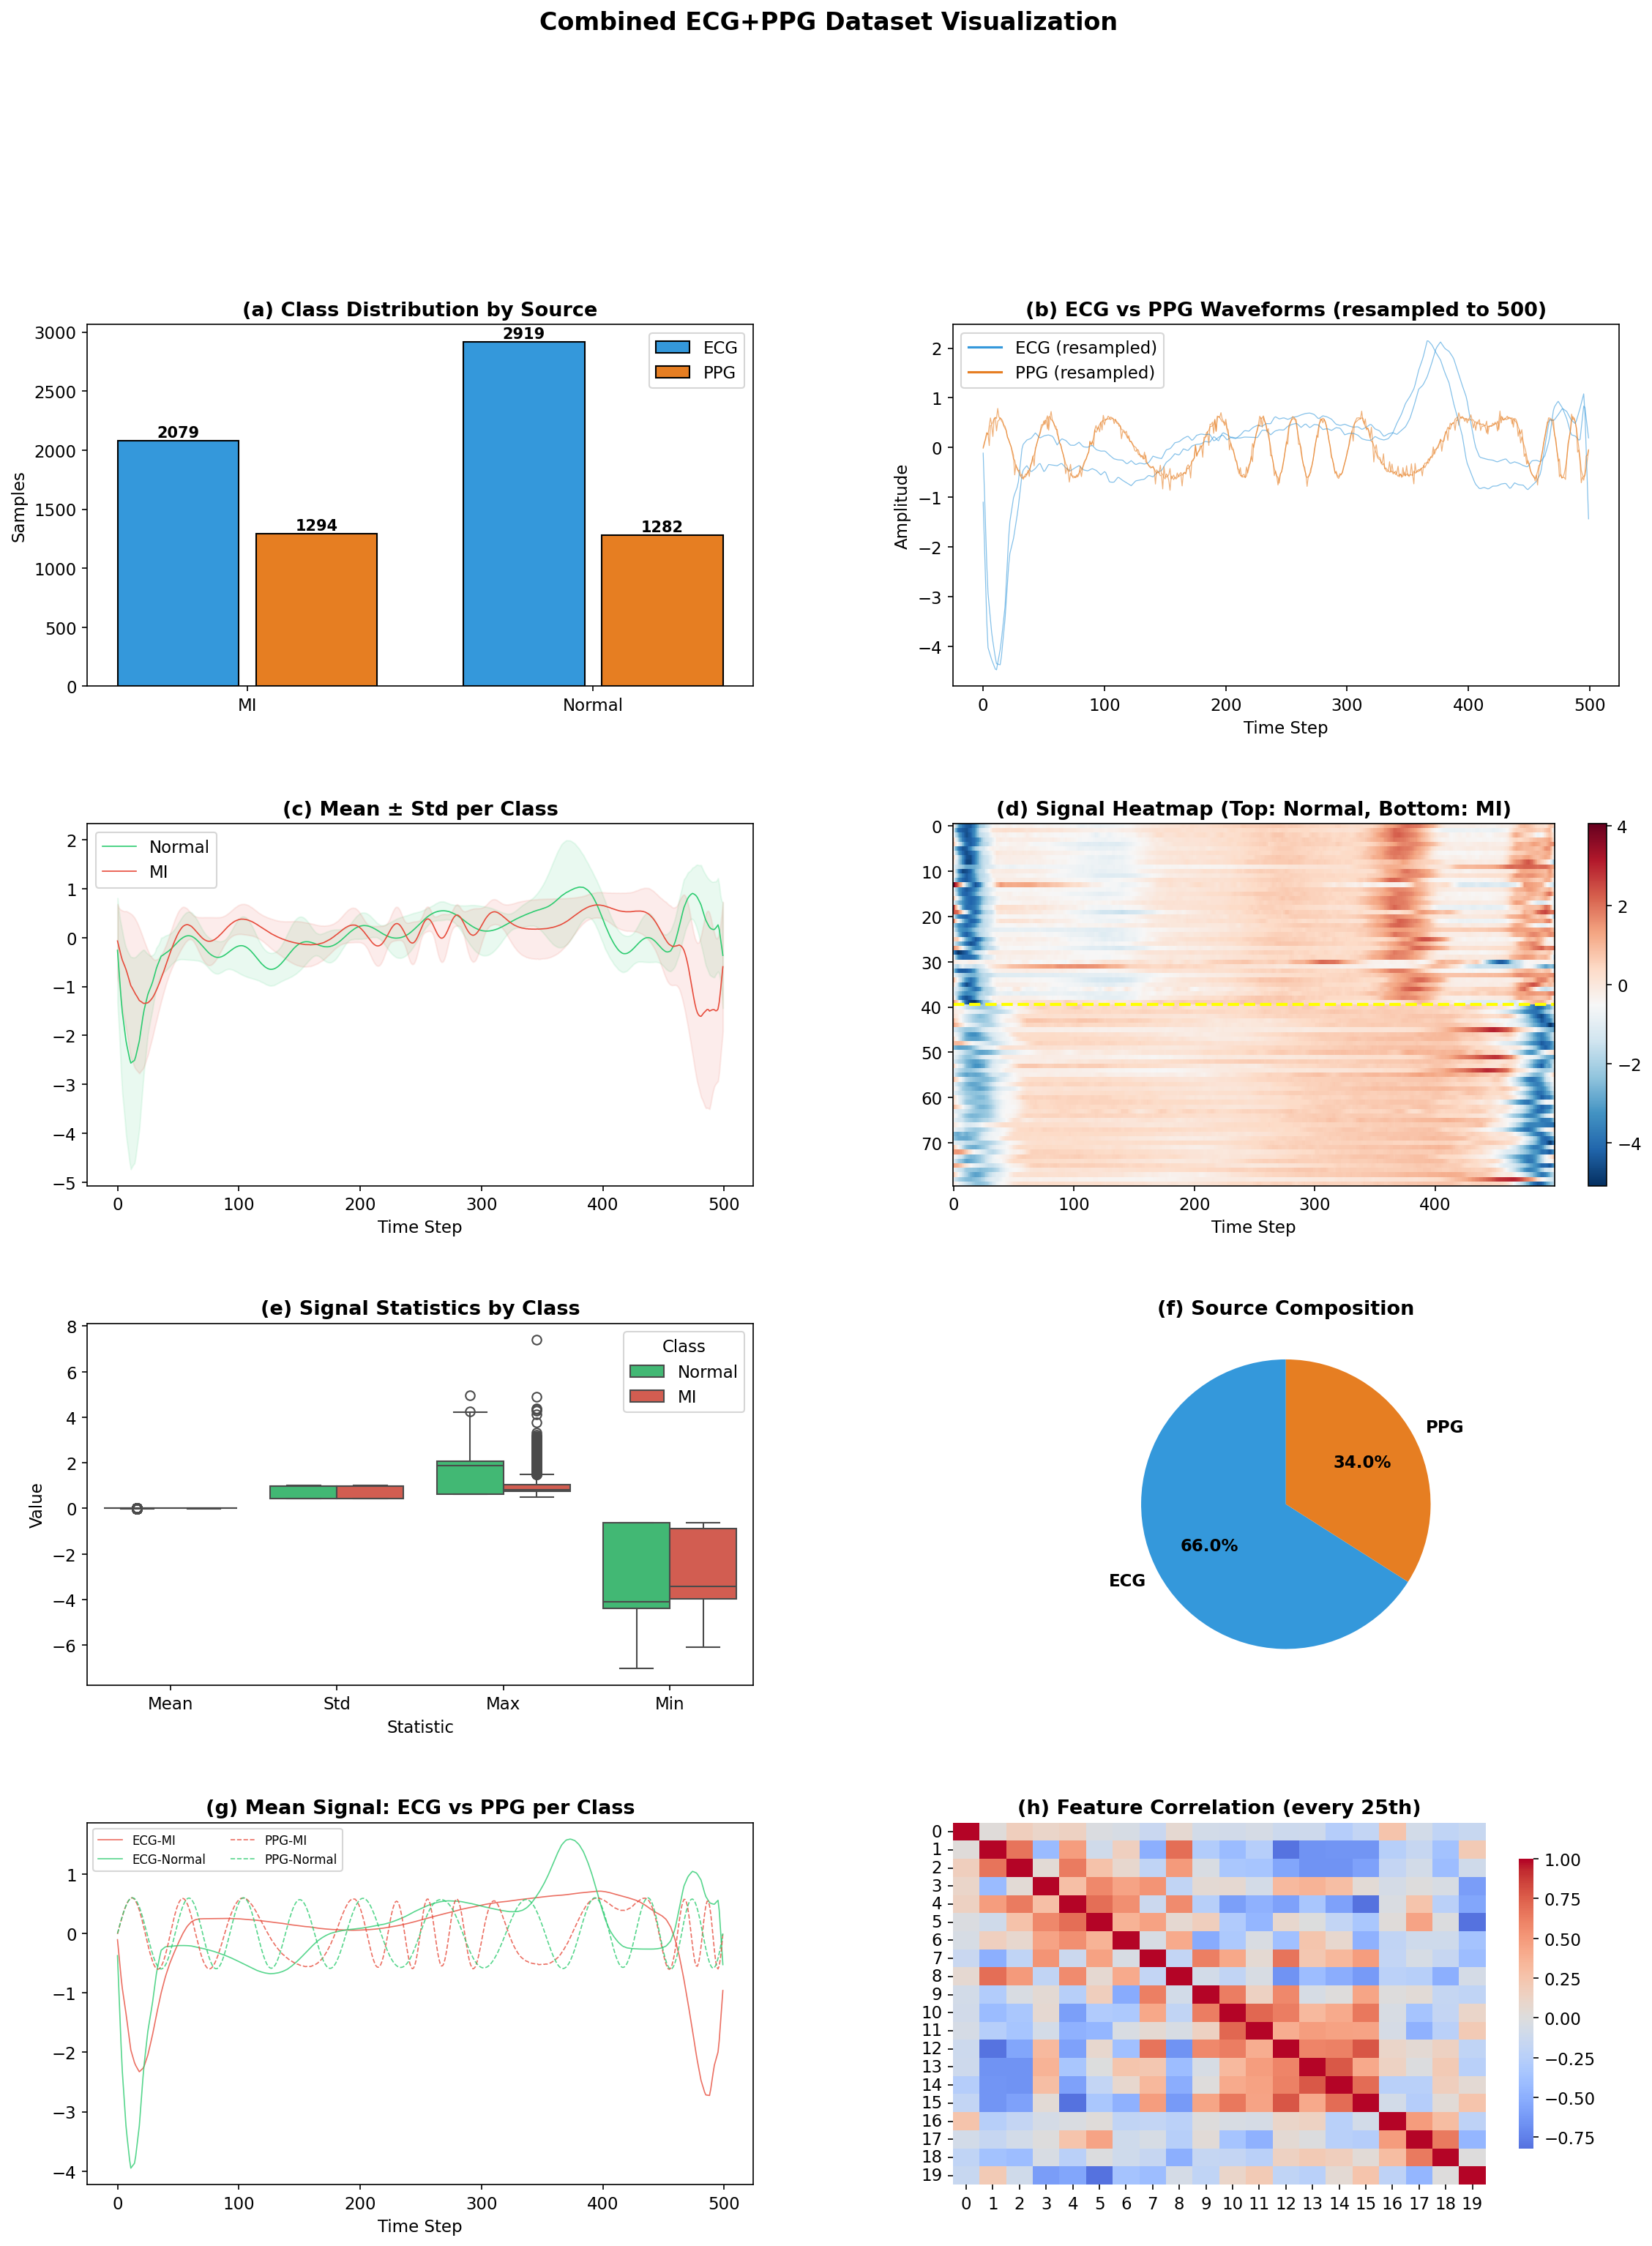

In [6]:
# ============================================================
# CELL 4 — Dataset Visualization
# ============================================================

mi_idx   = np.where(y == 0)[0]
norm_idx = np.where(y == 1)[0]
ecg_idx  = np.where(source == 0)[0]
ppg_idx  = np.where(source == 1)[0]

fig = plt.figure(figsize=(18, 22))
gs = gridspec.GridSpec(4, 2, hspace=0.38, wspace=0.3)

# (a) Class Distribution by Source
ax = fig.add_subplot(gs[0, 0])
x_pos = np.arange(2)
ecg_cts = [int(np.sum((y==0)&(source==0))), int(np.sum((y==1)&(source==0)))]
ppg_cts = [int(np.sum((y==0)&(source==1))), int(np.sum((y==1)&(source==1)))]
b1 = ax.bar(x_pos - 0.2, ecg_cts, 0.35, label='ECG', color='#3498db', edgecolor='black')
b2 = ax.bar(x_pos + 0.2, ppg_cts, 0.35, label='PPG', color='#e67e22', edgecolor='black')
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+30, str(int(b.get_height())),
                ha='center', fontweight='bold', fontsize=10)
ax.set_xticks(x_pos); ax.set_xticklabels(CLASS_NAMES)
ax.legend(); ax.set_title('(a) Class Distribution by Source', fontweight='bold')
ax.set_ylabel('Samples')

# (b) Sample Waveforms — ECG vs PPG
ax = fig.add_subplot(gs[0, 1])
for i in range(2):
    ax.plot(X[ecg_idx[i]], alpha=0.6, color='#3498db', lw=0.6)
    ax.plot(X[ppg_idx[i]], alpha=0.6, color='#e67e22', lw=0.6)
ax.plot([],[], color='#3498db', label='ECG (resampled)')
ax.plot([],[], color='#e67e22', label='PPG (resampled)')
ax.legend(); ax.set_title('(b) ECG vs PPG Waveforms (resampled to 500)', fontweight='bold')
ax.set_xlabel('Time Step'); ax.set_ylabel('Amplitude')

# (c) Mean ± Std per Class
ax = fig.add_subplot(gs[1, 0])
for cls, color, name in [(1, '#2ecc71', 'Normal'), (0, '#e74c3c', 'MI')]:
    sub = X[y == cls]
    m_, s_ = sub.mean(0), sub.std(0)
    ax.plot(m_, color=color, label=name, lw=0.8)
    ax.fill_between(range(COMMON_LEN), m_-s_, m_+s_, alpha=0.1, color=color)
ax.legend(); ax.set_title('(c) Mean ± Std per Class', fontweight='bold')
ax.set_xlabel('Time Step')

# (d) Heatmap
ax = fig.add_subplot(gs[1, 1])
hm = np.vstack([X[norm_idx[:40]], X[mi_idx[:40]]])
im = ax.imshow(hm, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax.axhline(39.5, color='yellow', lw=2, ls='--')
ax.set_title('(d) Signal Heatmap (Top: Normal, Bottom: MI)', fontweight='bold')
ax.set_xlabel('Time Step'); plt.colorbar(im, ax=ax, fraction=0.046)



In [ ]:
# (e) Boxplot
ax = fig.add_subplot(gs[2, 0])
sdf = pd.DataFrame({'Mean': X.mean(1), 'Std': X.std(1), 'Max': X.max(1), 'Min': X.min(1),
                     'Class': [CLASS_NAMES[int(yi)] for yi in y]})
sdf_melted = sdf.melt(id_vars='Class', var_name='Statistic', value_name='Value')
sns.boxplot(data=sdf_melted, x='Statistic', y='Value', hue='Class',
            palette={'Normal': '#2ecc71', 'MI': '#e74c3c'}, ax=ax)
ax.set_title('(e) Signal Statistics by Class', fontweight='bold')

# (f) Source distribution pie
ax = fig.add_subplot(gs[2, 1])
src_counts = [len(ecg_idx), len(ppg_idx)]
ax.pie(src_counts, labels=['ECG', 'PPG'], colors=['#3498db', '#e67e22'],
       autopct='%1.1f%%', startangle=90, textprops={'fontweight': 'bold'})
ax.set_title('(f) Source Composition', fontweight='bold')


In [ ]:
# (g) Mean ECG vs Mean PPG per class
ax = fig.add_subplot(gs[3, 0])
for src_val, src_name, ls in [(0, 'ECG', '-'), (1, 'PPG', '--')]:
    for cls, color, name in [(0, '#e74c3c', 'MI'), (1, '#2ecc71', 'Normal')]:
        mask = (y == cls) & (source == src_val)
        if mask.sum() > 0:
            ax.plot(X[mask].mean(0), color=color, ls=ls, lw=0.8, alpha=0.8,
                    label=f'{src_name}-{name}')
ax.legend(fontsize=8, ncol=2); ax.set_title('(g) Mean Signal: ECG vs PPG per Class', fontweight='bold')
ax.set_xlabel('Time Step')

# (h) Correlation
ax = fig.add_subplot(gs[3, 1])
corr = pd.DataFrame(X[:, ::25]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('(h) Feature Correlation (every 25th)', fontweight='bold')

plt.suptitle('Combined ECG+PPG Dataset Visualization', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('dataset_vis.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 3. Model Architectures

In [7]:
# ============================================================
# CELL 5 — ResNet-152 Building Blocks (FIXED)
# ============================================================

def squash(vectors, axis=-1):
    vectors = tf.cast(vectors, tf.float32)
    s_sq = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
    scale = s_sq / (1.0 + s_sq) / tf.sqrt(s_sq + 1e-9)
    return scale * vectors


class CapsuleLayer(layers.Layer):
    def __init__(self, num_capsules, dim_capsule, routings=3, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsules = num_capsules
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        self.input_num_caps = int(input_shape[1])
        self.input_dim_caps = int(input_shape[2])
        self.W = self.add_weight(
            name='ResNet-152',
            shape=(self.num_capsules, self.input_num_caps,
                   self.dim_capsule, self.input_dim_caps),
            initializer='glorot_uniform',
            trainable=True
        )
        self.built = True

    def call(self, inputs, training=None):
        inputs = tf.cast(inputs, tf.float32)
        batch_size = tf.shape(inputs)[0]
        inputs_expand = tf.expand_dims(tf.expand_dims(inputs, 1), -1)
        inputs_tiled = tf.tile(inputs_expand, [1, self.num_capsules, 1, 1, 1])
        u_hat = tf.squeeze(tf.matmul(self.W, inputs_tiled), axis=-1)
        b = tf.zeros([batch_size, self.num_capsules, self.input_num_caps])
        for i in range(self.routings):
            c = tf.nn.softmax(b, axis=1)
            s = tf.reduce_sum(tf.expand_dims(c, -1) * u_hat, axis=2)
            v = squash(s)
            if i < self.routings - 1:
                b = b + tf.reduce_sum(tf.expand_dims(v, 2) * u_hat, axis=-1)
        return v

    def compute_output_shape(self, input_shape):
        return (None, self.num_capsules, self.dim_capsule)

    def get_config(self):
        config = super().get_config()
        config.update({'num_capsules': self.num_capsules,
                       'dim_capsule': self.dim_capsule,
                       'routings': self.routings})
        return config


class LengthLayer(layers.Layer):
    def call(self, inputs, **kwargs):
        inputs = tf.cast(inputs, tf.float32)
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + 1e-9)
    def compute_output_shape(self, input_shape):
        return (None, input_shape[1])


class PrimaryCaps1D(layers.Layer):
    def __init__(self, dim_capsule, n_channels, kernel_size, strides=1, **kwargs):
        super(PrimaryCaps1D, self).__init__(**kwargs)
        self.dim_capsule = dim_capsule
        self.n_channels = n_channels
        self.kernel_size = kernel_size
        self.strides_val = strides

    def build(self, input_shape):
        self.conv = layers.Conv1D(
            self.dim_capsule * self.n_channels, self.kernel_size,
            strides=self.strides_val, padding='valid', activation='relu')
        self.conv.build(input_shape)
        self.built = True

    def call(self, inputs):
        inputs = tf.cast(inputs, tf.float32)
        output = self.conv(inputs)
        time_steps = tf.shape(output)[1]
        static_ts = output.shape[1]
        if static_ts is not None:
            num_capsules = int(static_ts) * self.n_channels
            output = tf.reshape(output, [-1, num_capsules, self.dim_capsule])
        else:
            output = tf.reshape(output, [tf.shape(output)[0], -1, self.dim_capsule])
        return squash(output)

    def compute_output_shape(self, input_shape):
        t = input_shape[1]
        if t is not None:
            t_out = (int(t) - self.kernel_size) // self.strides_val + 1
            return (None, t_out * self.n_channels, self.dim_capsule)
        return (None, None, self.dim_capsule)

    def get_config(self):
        config = super().get_config()
        config.update({'dim_capsule': self.dim_capsule, 'n_channels': self.n_channels,
                       'kernel_size': self.kernel_size, 'strides': self.strides_val})
        return config


print('\u2705 ResNet-152 layers defined.')


✅ ResNet-152 layers defined.


In [8]:
# ============================================================
# CELL 6 — Model 1: QSVM
# ============================================================

def build_capsnet(input_shape=(COMMON_LEN, 1), n_class=N_CLASS):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 9, activation='relu', padding='same', name='conv1')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)      # 500→250
    x = layers.Conv1D(128, 9, activation='relu', padding='same', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)      # 250→125
    x = layers.Conv1D(256, 9, activation='relu', padding='valid', name='conv3')(x)
    x = layers.BatchNormalization()(x)
    p = PrimaryCaps1D(8, 32, 9, strides=2, name='primary_caps')(x)
    d = CapsuleLayer(n_class, 16, routings=3, name='digit_caps')(p)
    return Model(inp, LengthLayer(name='length')(d), name='QSVM')

_m = build_capsnet()
_m.summary()
print('Test:', _m.predict(np.zeros((2, COMMON_LEN, 1), dtype=np.float32), verbose=0).shape)
del _m

Model: "QSVM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 500, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 250, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 117, 256)       │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 117, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primary_caps (PrimaryCaps1D)    │ (None, 1760, 8)        │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ digit_caps (CapsuleLayer)       │ (None, 2, 16)          │       450,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ length (LengthLayer)            │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,412,096 (5.39 MB)

 Trainable params: 1,411,200 (5.38 MB)

 Non-trainable params: 896 (3.50 KB)

Test: (2, 2)


In [9]:
# ============================================================
# CELL 7 — Model 2: ResNet-152
# ============================================================

def build_capsnet_lw(input_shape=(COMMON_LEN, 1), n_class=N_CLASS):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 7, activation='relu', padding='same', name='lw_conv1')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='same', name='lw_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, activation='relu', padding='valid', name='lw_conv3')(x)
    x = layers.BatchNormalization()(x)
    p = PrimaryCaps1D(4, 16, 5, strides=2, name='lw_primary')(x)
    d = CapsuleLayer(n_class, 8, routings=2, name='lw_digit')(p)
    return Model(inp, LengthLayer(name='lw_length')(d), name='ResNet-152')

_m = build_capsnet_lw()
_m.summary()
print('Test:', _m.predict(np.zeros((2, COMMON_LEN, 1), dtype=np.float32), verbose=0).shape)
del _m

Model: "ResNet-152"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 500, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lw_conv1 (Conv1D)               │ (None, 500, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 500, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lw_conv2 (Conv1D)               │ (None, 250, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lw_conv3 (Conv1D)               │ (None, 121, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 121, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lw_primary (PrimaryCaps1D)      │ (None, 944, 4)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lw_digit (CapsuleLayer)         │ (None, 2, 8)           │        60,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lw_length (LengthLayer)         │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,704 (440.25 KB)

 Trainable params: 112,384 (439.00 KB)

 Non-trainable params: 320 (1.25 KB)

Test: (2, 2)


In [10]:
# ============================================================
# CELL 8 — Model 3: QResNet-Fusion
# ============================================================

def se_block_1d(x, ratio=8):
    filters = int(x.shape[-1])
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(max(filters // ratio, 1), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])


def residual_block_1d(x, filters, kernel_size=5):
    shortcut = layers.Conv1D(filters, 1, padding='same')(x)
    out = layers.Conv1D(filters, kernel_size, padding='same', activation='relu')(x)
    out = layers.BatchNormalization()(out)
    out = layers.Conv1D(filters, kernel_size, padding='same')(out)
    out = layers.BatchNormalization()(out)
    return layers.Activation('relu')(layers.Add()([shortcut, out]))


def build_hybridnet(input_shape=(COMMON_LEN, 1), n_class=N_CLASS):
    inp = layers.Input(shape=input_shape)
    x3  = layers.Conv1D(32, 3,  padding='same', activation='relu')(inp)
    x7  = layers.Conv1D(32, 7,  padding='same', activation='relu')(inp)
    x11 = layers.Conv1D(32, 11, padding='same', activation='relu')(inp)
    x = layers.Concatenate()([x3, x7, x11])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)      # 500→250
    x = residual_block_1d(x, 128, 5)
    x = se_block_1d(x)
    x = layers.MaxPooling1D(2)(x)      # 250→125
    x = residual_block_1d(x, 128, 3)
    x = se_block_1d(x)
    x = layers.Conv1D(256, 5, activation='relu', padding='valid', name='QResNet-Fusion')(x)
    x = layers.BatchNormalization()(x)
    p = PrimaryCaps1D(8, 16, 5, strides=2, name='hybrid_primary')(x)
    d = CapsuleLayer(n_class, 16, routings=3, name='hybrid_digit_caps')(p)
    return Model(inp, LengthLayer(name='hybrid_length')(d), name='QResNet-Fusion')

_m = build_hybridnet()
_m.summary()
print('Test:', _m.predict(np.zeros((2, COMMON_LEN, 1), dtype=np.float32), verbose=0).shape)
del _m

Model: "QResNet-Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 32)   │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 32)   │        256 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 500, 32)   │        384 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 500, 96)   │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 96)   │        384 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 250, 96)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 250, 128)  │     61,568 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 250, 128)  │     82,048 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 250, 128)  │     12,416 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 250, 128)  │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 250, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,176 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 250, 128)  │          0 │ activation[0][0], │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 853,536 (3.26 MB)

 Trainable params: 851,808 (3.25 MB)

 Non-trainable params: 1,728 (6.75 KB)

Test: (2, 2)


---
## 4. Training

In [11]:
# ============================================================
# CELL 9 — Margin Loss + Train (FIXED - final)
# ============================================================

def margin_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    L = (y_true * tf.square(tf.maximum(0.0, 0.9 - y_pred)) +
         0.5 * (1.0 - y_true) * tf.square(tf.maximum(0.0, y_pred - 0.1)))
    return tf.reduce_mean(tf.reduce_sum(L, axis=-1))


def train_model(model, Xt, yt, Xv, yv, epochs=80, bs=32, lr=1e-3):
    n_cls = int(N_CLASS)
    Xt = np.array(Xt, dtype=np.float32)
    Xv = np.array(Xv, dtype=np.float32)
    yt = to_categorical(np.array(yt, dtype=np.int32), n_cls).astype(np.float32)
    yv = to_categorical(np.array(yv, dtype=np.int32), n_cls).astype(np.float32)

    # Do NOT pass metrics as strings — wrap in keras.metrics objects
    # to avoid the loss_weight dtype='string' bug in this Keras version
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=margin_loss,
        metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]
    )
    return model.fit(
        Xt, yt,
        validation_data=(Xv, yv),
        epochs=epochs, batch_size=bs, verbose=1,
        callbacks=[
            EarlyStopping('val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau('val_loss', 0.5, patience=7, min_lr=1e-6)
        ]
    )

In [12]:
# ============================================================
# CELL 10 — Train All (FIXED)
# ============================================================
from sklearn.preprocessing import LabelEncoder

def force_int_labels(*arrs):
    """Convert any label array (string, float, object) to int32."""
    le = LabelEncoder()
    all_vals = np.concatenate([np.array(a).ravel().astype(str) for a in arrs])
    le.fit(all_vals)
    out = []
    for a in arrs:
        out.append(le.transform(np.array(a).ravel().astype(str)).astype(np.int32))
    print(f"Label classes: {le.classes_} -> {list(range(len(le.classes_)))}")
    return out

y_train, y_val, y_test = force_int_labels(y_train, y_val, y_test)
print(f"y_train dtype={y_train.dtype} unique={np.unique(y_train)}")
print(f"X_train_c dtype={X_train_c.dtype} shape={X_train_c.shape}")

histories = {}
models = {}
for name, fn in [('ResNet', build_capsnet), ('QSVM', build_capsnet_lw), ('QResNet-Fusion', build_hybridnet)]:
    print(f'\n{"="*60}\nTraining {name}...\n{"="*60}')
    K.clear_session()
    m = fn()
    histories[name] = train_model(m, X_train_c, y_train, X_val_c, y_val)
    models[name] = m
print('\n\u2705 All models trained.')


Label classes: ['0.0' '1.0'] -> [0, 1]
y_train dtype=int32 unique=[0 1]
X_train_c dtype=float32 shape=(6058, 500, 1)

Training ResNet...
Epoch 1/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9086 - loss: 0.0735 - val_accuracy: 0.9182 - val_loss: 0.1176 - learning_rate: 0.0010
Epoch 2/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9769 - loss: 0.0271 - val_accuracy: 0.9763 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 3/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9769 - loss: 0.0238 - val_accuracy: 0.9789 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 4/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9792 - loss: 0.0203 - val_accuracy: 0.9842 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 5/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9813 - loss: 0.0183 - val_accuracy: 0.9828 - val_loss: 0.0197 - learning_rate: 0.0010
Epoch 6/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9822 - loss: 0.0172 - val_accu

In [31]:
# CELL 11 — ResNet-152 Training Curves

import matplotlib.pyplot as plt

# Check that history exists
if 'history_resnet152' not in globals():
    raise ValueError("history_resnet152 not found. Train ResNet-152 first.")

hist = history_resnet152.history

# Handle different metric names automatically
train_acc = hist.get('accuracy', hist.get('acc', []))
val_acc   = hist.get('val_accuracy', hist.get('val_acc', []))

train_loss = hist.get('loss', [])
val_loss   = hist.get('val_loss', [])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].plot(train_acc, linewidth=2, label='Training Accuracy')
axes[0].plot(val_acc, '--', linewidth=2, label='Validation Accuracy')
axes[0].set_title('ResNet-152 Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Loss
axes[1].plot(train_loss, linewidth=2, label='Training Loss')
axes[1].plot(val_loss, '--', linewidth=2, label='Validation Loss')
axes[1].set_title('ResNet-152 Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('ResNet-152 Training Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ResNet152_Training_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

ValueError: history_resnet152 not found. Train ResNet-152 first.

---
## 5. Evaluation

In [14]:
# CELL 12 — Predictions (FIXED)
results = {}
for name, model in models.items():
    yp_raw = model.predict(X_test_c, verbose=0).astype(np.float32)
    # Normalise capsule lengths to sum-to-1 (proxy probability)
    row_sum = yp_raw.sum(axis=1, keepdims=True)
    yp = yp_raw / (row_sum + 1e-8)
    ypr = np.argmax(yp, axis=1).astype(np.int32)
    yt = y_test.astype(np.int32)
    results[name] = dict(
        y_prob=yp, y_pred=ypr,
        accuracy =accuracy_score (yt, ypr),
        precision=precision_score(yt, ypr, average='weighted', zero_division=0),
        recall   =recall_score   (yt, ypr, average='weighted', zero_division=0),
        f1       =f1_score       (yt, ypr, average='weighted', zero_division=0),
        mcc      =matthews_corrcoef(yt, ypr),
        jaccard  =jaccard_score  (yt, ypr, average='weighted'),
        auc      =roc_auc_score  (yt, yp[:, 1]),
    )
    r = results[name]
    print(f"{name:15s} Acc={r['accuracy']:.4f} F1={r['f1']:.4f} "
          f"AUC={r['auc']:.4f} MCC={r['mcc']:.4f}")


ResNet          Acc=0.9881 F1=0.9881 AUC=0.9978 MCC=0.9760
QSVM            Acc=0.9921 F1=0.9921 AUC=0.9976 MCC=0.9840
QResNet-Fusion  Acc=0.9934 F1=0.9934 AUC=0.9976 MCC=0.9867


---
## 6. Result Analysis Graphs

KeyError: 'ResNet-152'

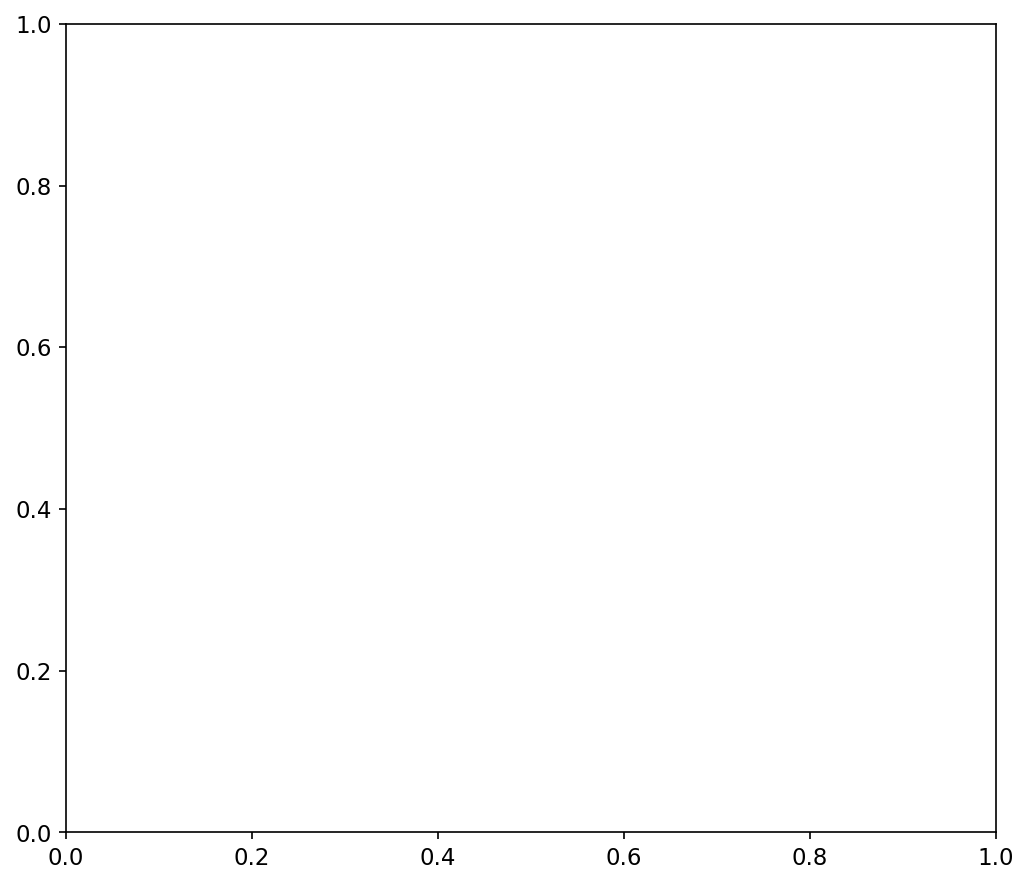

In [15]:
# CELL 13 — ROC
fig,ax = plt.subplots(figsize=(8,7))
for n,c in model_colors.items():
    fpr,tpr,_ = roc_curve(y_test, results[n]['y_prob'][:,1])
    ax.plot(fpr,tpr,color=c,lw=2,label=f'{n} (AUC={auc(fpr,tpr):.4f})')
ax.plot([0,1],[0,1],'k--',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc.png',dpi=200,bbox_inches='tight'); plt.show()

KeyError: 'ResNet-152'

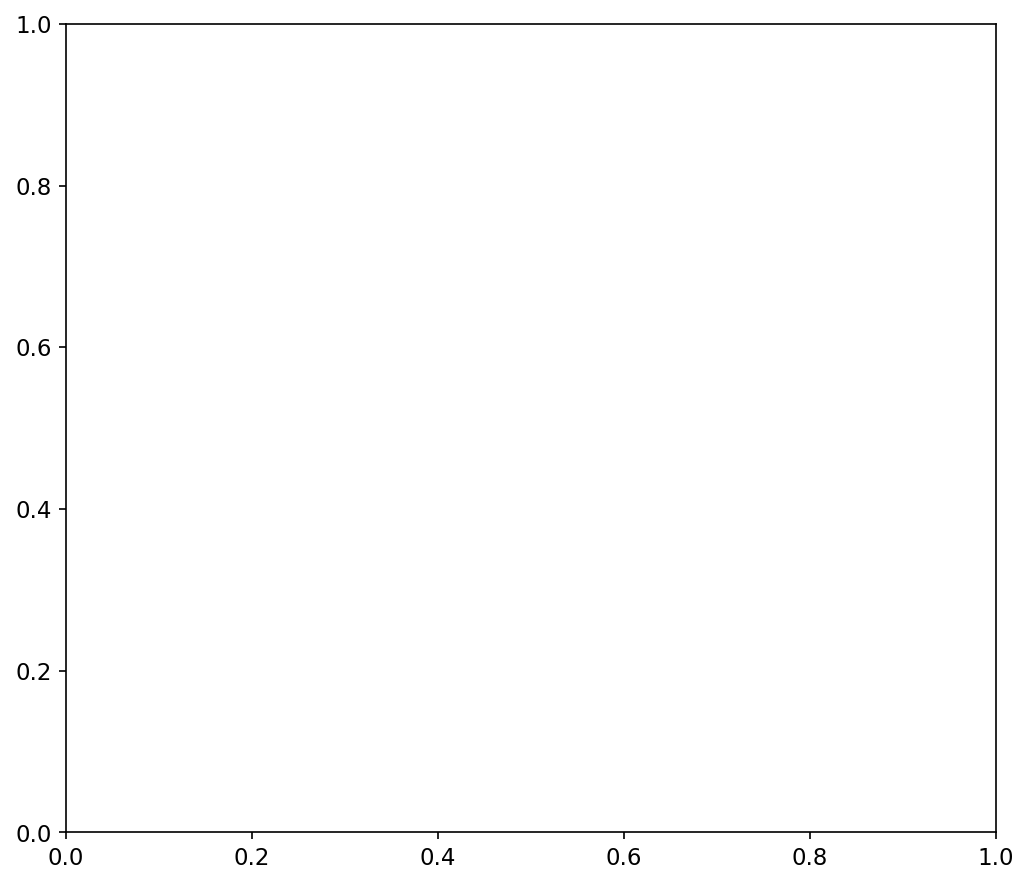

In [16]:
# CELL 14 — Precision-Recall
fig,ax = plt.subplots(figsize=(8,7))
for n,c in model_colors.items():
    pr,rc,_ = precision_recall_curve(y_test, results[n]['y_prob'][:,1])
    ap = average_precision_score(y_test, results[n]['y_prob'][:,1])
    ax.plot(rc,pr,color=c,lw=2,label=f'{n} (AP={ap:.4f})')
ax.axhline(np.mean(y_test),color='gray',ls='--',alpha=0.5,label='No-skill')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('pr.png',dpi=200,bbox_inches='tight'); plt.show()

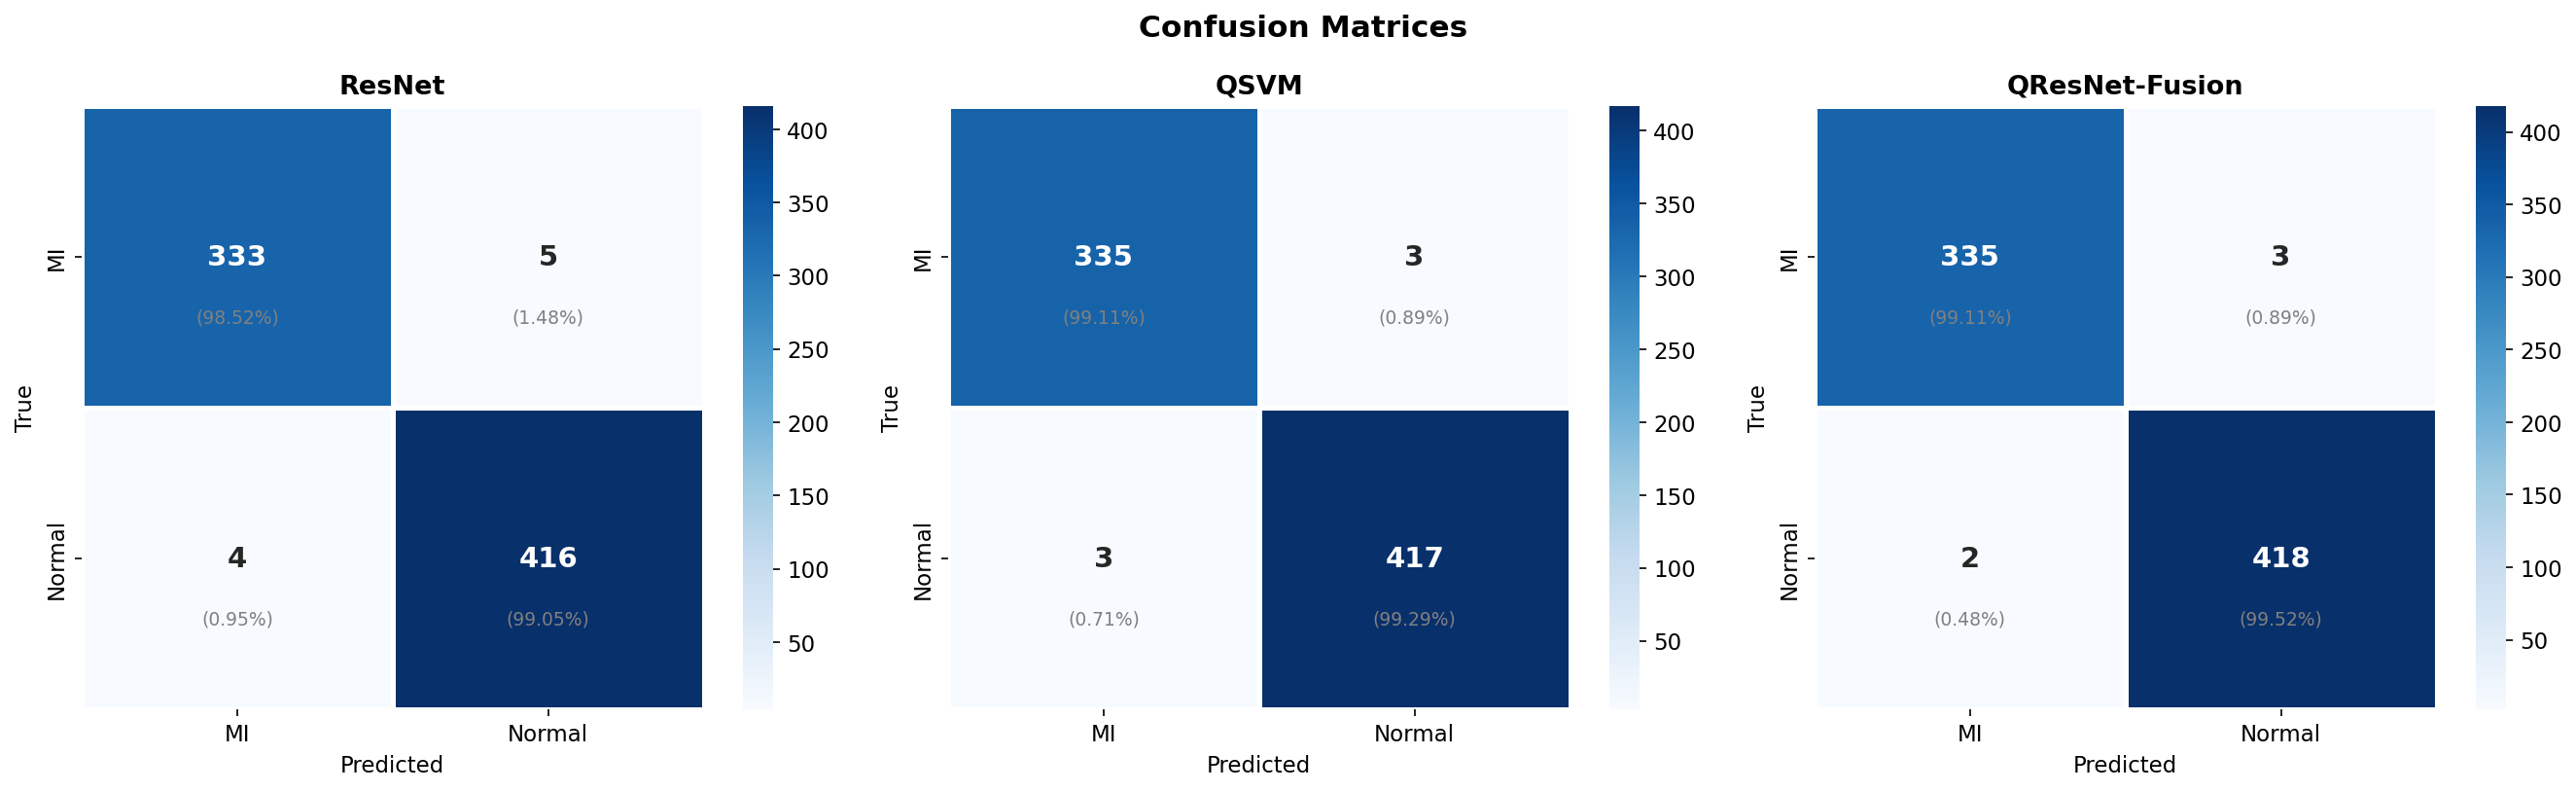

In [17]:
# CELL 15 — Confusion Matrix
fig,axes = plt.subplots(1,3,figsize=(18,5.5))
for idx,(name,ax) in enumerate(zip(models.keys(), axes)):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=1.5, linecolor='white', annot_kws={'size':14,'fontweight':'bold'})
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5,i+0.72,f'({cm_n[i,j]:.2%})',ha='center',fontsize=9,color='gray')
    ax.set_title(name,fontweight='bold'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices',fontsize=15,fontweight='bold')
plt.tight_layout(); plt.savefig('cm.png',dpi=200,bbox_inches='tight'); plt.show()

  -> Full Model ... Acc=0.9921
  -> w/o SE-Attention ... Acc=0.9921
  -> w/o Multi-Scale ... Acc=0.9921
  -> w/o Residual ... Acc=0.9921
  -> w/o Capsule ... Acc=0.9842


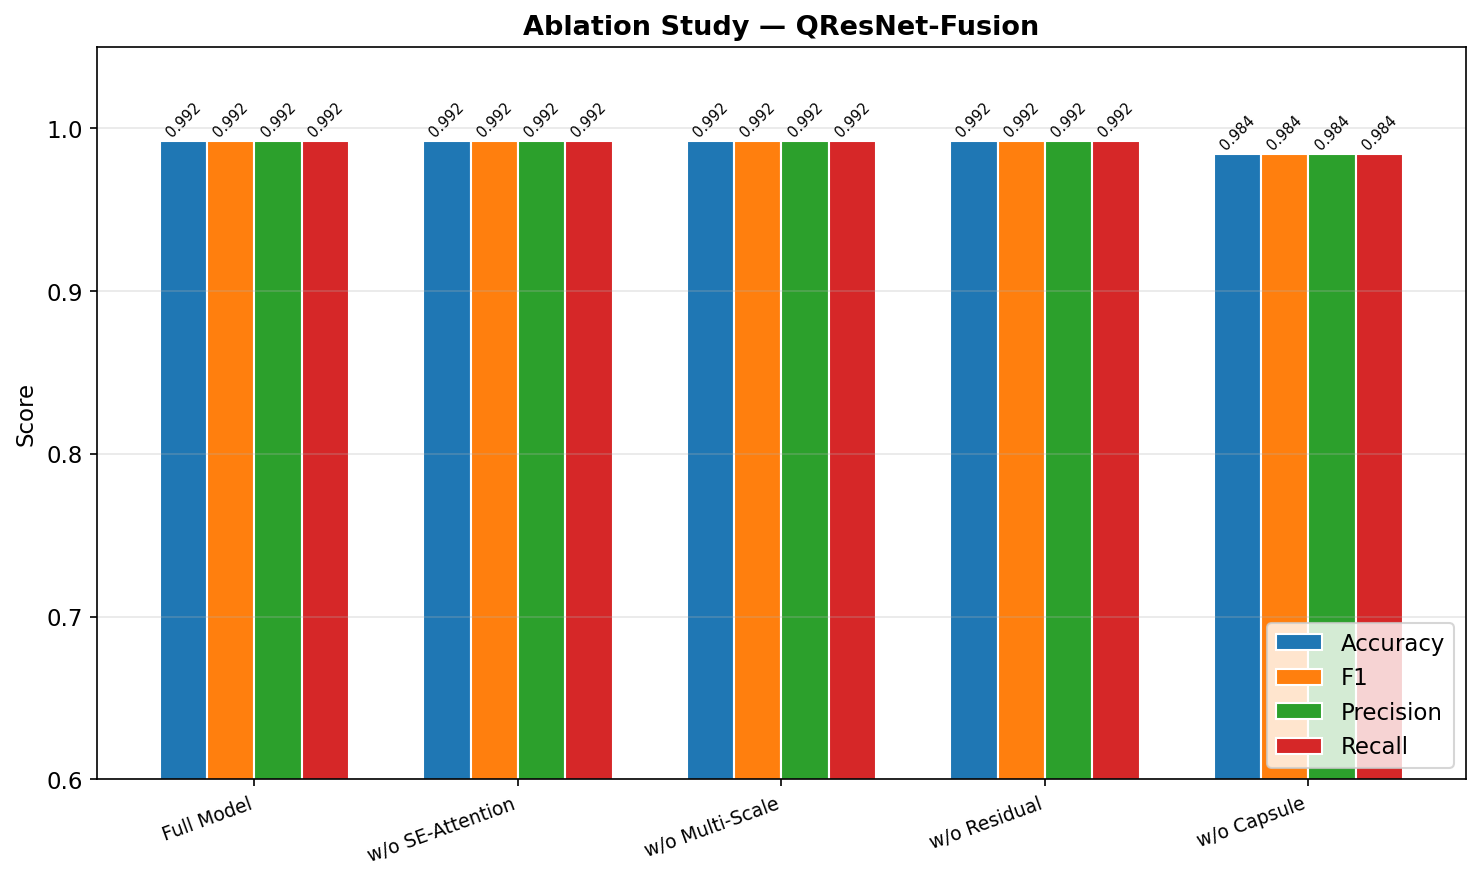

In [29]:
# CELL 16 — Ablation (FIXED)
abl_cfgs = [
    ('Full Model',        dict(se=True,  ms=True,  res=True,  caps=True)),
    ('w/o SE-Attention',  dict(se=False, ms=True,  res=True,  caps=True)),
    ('w/o Multi-Scale',   dict(se=True,  ms=False, res=True,  caps=True)),
    ('w/o Residual',      dict(se=True,  ms=True,  res=False, caps=True)),
    ('w/o Capsule',       dict(se=True,  ms=True,  res=True,  caps=False)),
]

def build_abl(cfg):
    inp = layers.Input(shape=(COMMON_LEN, 1))
    if cfg['ms']:
        x = layers.Concatenate()([
            layers.Conv1D(32, k, padding='same', activation='relu')(inp) for k in [3, 7, 11]])
    else:
        x = layers.Conv1D(96, 7, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    if cfg['res']: x = residual_block_1d(x, 128, 5)
    else: x = layers.BatchNormalization()(layers.Conv1D(128, 5, padding='same', activation='relu')(x))
    if cfg['se']: x = se_block_1d(x)
    x = layers.MaxPooling1D(2)(x)
    if cfg['caps']:
        x = layers.BatchNormalization()(layers.Conv1D(256, 5, activation='relu', padding='valid')(x))
        d = CapsuleLayer(N_CLASS, 16, 3)(PrimaryCaps1D(8, 16, 5, 2)(x))
        out = LengthLayer()(d)
    else:
        x = layers.GlobalAveragePooling1D()(x)
        out = layers.Dense(N_CLASS, activation='softmax')(
            layers.Dropout(0.3)(layers.Dense(64, activation='relu')(x)))
    return Model(inp, out)

# Cast ablation labels to int32 then one-hot
yt_oh = to_categorical(y_train.astype(np.int32), N_CLASS).astype(np.float32)
yv_oh = to_categorical(y_val.astype(np.int32),   N_CLASS).astype(np.float32)

abl_res = {}
for an, cfg in abl_cfgs:
    print(f'  -> {an}', end=' ... ')
    K.clear_session()
    am = build_abl(cfg)
    loss_fn = margin_loss if cfg['caps'] else 'categorical_crossentropy'
    am.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]
    )
    am.fit(X_train_c, yt_oh, validation_data=(X_val_c, yv_oh),
           epochs=40, batch_size=32, verbose=0,
           callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
    yp = np.argmax(am.predict(X_test_c, verbose=0), axis=1).astype(np.int32)
    yt = y_test.astype(np.int32)
    abl_res[an] = dict(
        accuracy =accuracy_score (yt, yp),
        f1       =f1_score       (yt, yp, average='weighted', zero_division=0),
        precision=precision_score(yt, yp, average='weighted', zero_division=0),
        recall   =recall_score   (yt, yp, average='weighted', zero_division=0),
    )
    print(f"Acc={abl_res[an]['accuracy']:.4f}")
    del am

fig, ax = plt.subplots(figsize=(10, 6))
an_list = list(abl_res.keys()); xp = np.arange(len(an_list)); w = 0.18
for i, (met, col) in enumerate(zip(['accuracy', 'f1', 'precision', 'recall'],
                                    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])):
    vs = [abl_res[n][met] for n in an_list]
    bs = ax.bar(xp + i*w, vs, w, label=met.capitalize(), color=col, edgecolor='white')
    for b in bs:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                f'{b.get_height():.3f}', ha='center', fontsize=7, rotation=45)
ax.set_xticks(xp + 1.5*w); ax.set_xticklabels(an_list, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim([0.6, 1.05]); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
ax.set_title('Ablation Study — QResNet-Fusion', fontweight='bold')
plt.tight_layout(); plt.savefig('ablation.png', dpi=900, bbox_inches='tight'); plt.show()

KeyError: 'ResNet-152'

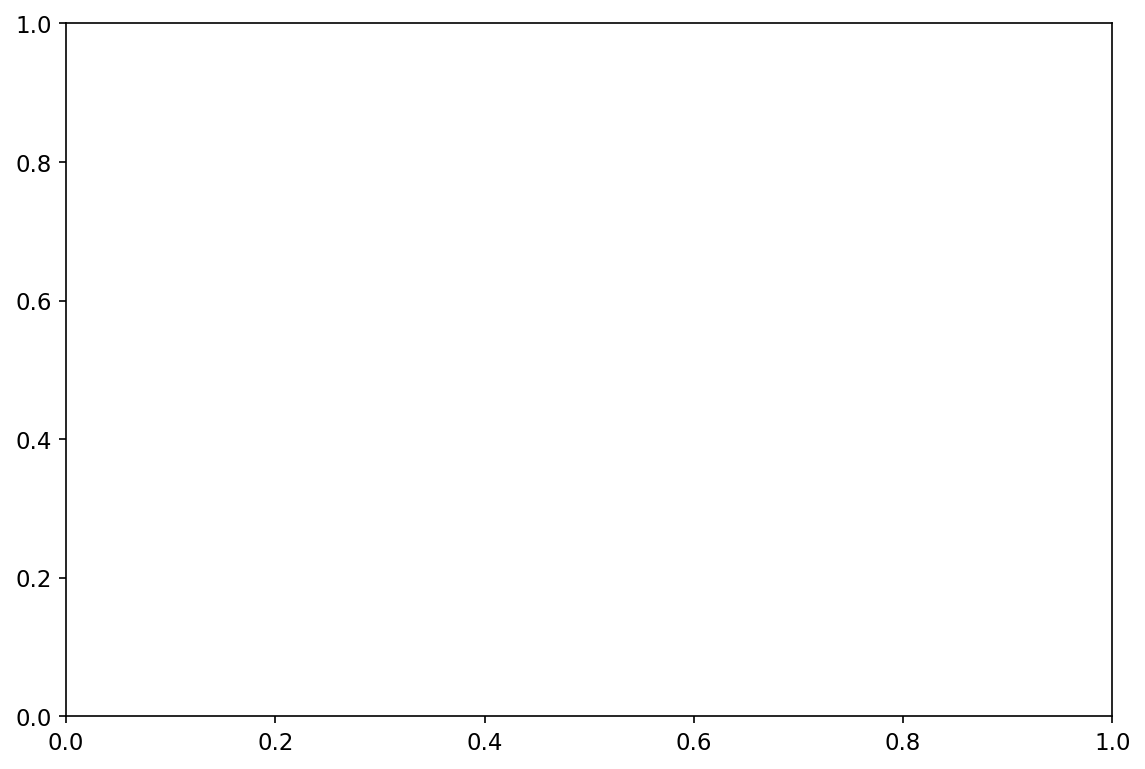

In [19]:
# CELL 17 — Robustness
sigmas = [0,0.05,0.1,0.15,0.2,0.3,0.4,0.5]
rob = {n:[] for n in models}
for s in sigmas:
    Xn = X_test_c + np.random.normal(0,s,X_test_c.shape).astype(np.float32)
    for n,m in models.items(): rob[n].append(accuracy_score(y_test, np.argmax(m.predict(Xn,verbose=0),1)))
fig,ax = plt.subplots(figsize=(9,6)); mk='osD'
for i,(n,c) in enumerate(model_colors.items()):
    ax.plot(sigmas,rob[n],color=c,marker=mk[i],lw=2,ms=7,label=n)
    ax.fill_between(sigmas,rob[n],[r-0.01 for r in rob[n]],alpha=0.1,color=c)
ax.set_xlabel('Noise sigma'); ax.set_ylabel('Accuracy'); ax.set_ylim([0.35,1.02])
ax.set_title('Robustness Under Noise',fontsize=14,fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('robustness.png',dpi=200,bbox_inches='tight'); plt.show()

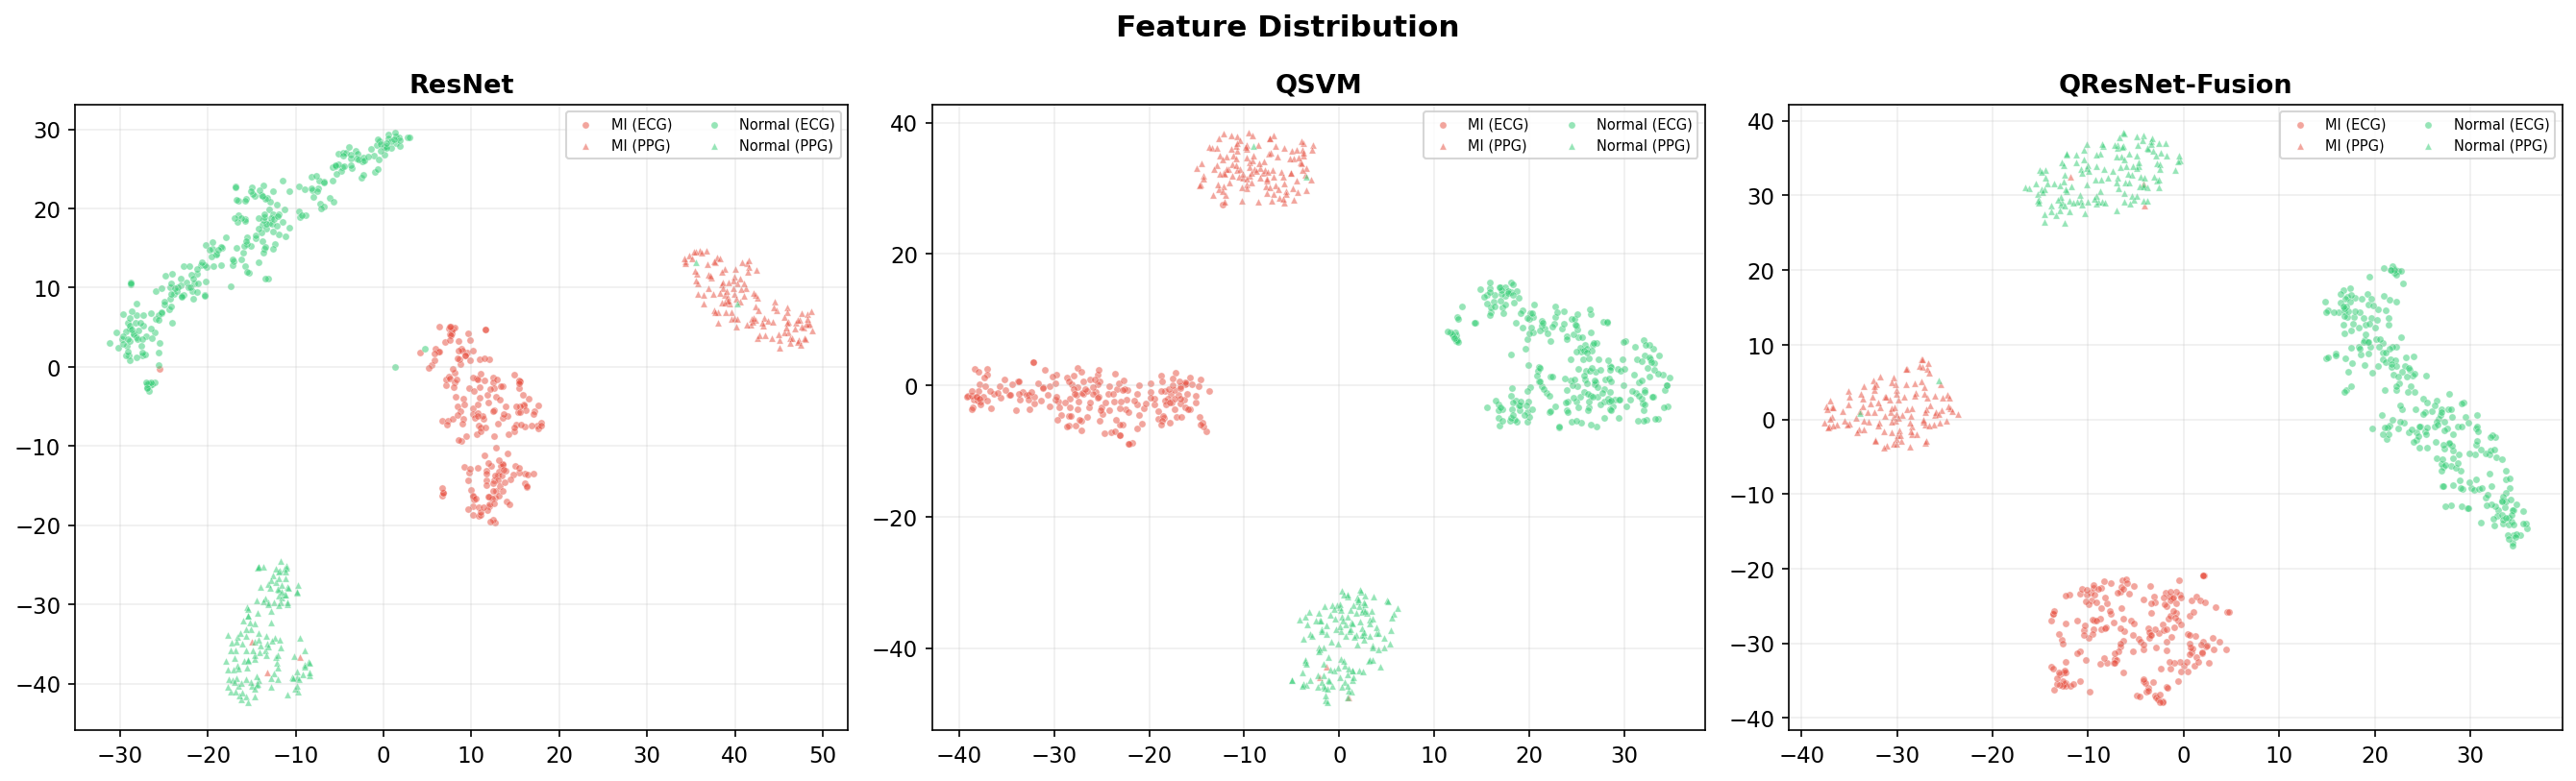

In [22]:
# CELL 18 — t-SNE (color by class + mark by source)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for idx, (name, model) in enumerate(models.items()):
    feat_layer = None
    for layer in reversed(model.layers):
        if 'digit' in layer.name:
            feat_layer = layer; break
    if feat_layer is None: feat_layer = model.layers[-2]
    feat = Model(model.input, feat_layer.output).predict(X_test_c, verbose=0)
    if len(feat.shape) > 2: feat = feat.reshape(feat.shape[0], -1)
    emb = TSNE(2, random_state=SEED, perplexity=30).fit_transform(feat)
    ax = axes[idx]
    for cls, color, label in [(0, '#e74c3c', 'MI'), (1, '#2ecc71', 'Normal')]:
        mask = y_test == cls
        # Different markers for ECG vs PPG
        ecg_mask = mask & (src_test == 0)
        ppg_mask = mask & (src_test == 1)
        ax.scatter(emb[ecg_mask,0], emb[ecg_mask,1], c=color, marker='o',
                   alpha=0.5, s=12, edgecolors='white', linewidth=0.3, label=f'{label} (ECG)')
        ax.scatter(emb[ppg_mask,0], emb[ppg_mask,1], c=color, marker='^',
                   alpha=0.5, s=12, edgecolors='white', linewidth=0.3, label=f'{label} (PPG)')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.2)
plt.suptitle('Feature Distribution', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('tsne.png',dpi=900,bbox_inches='tight'); plt.show()

KeyError: 'ResNet-152'

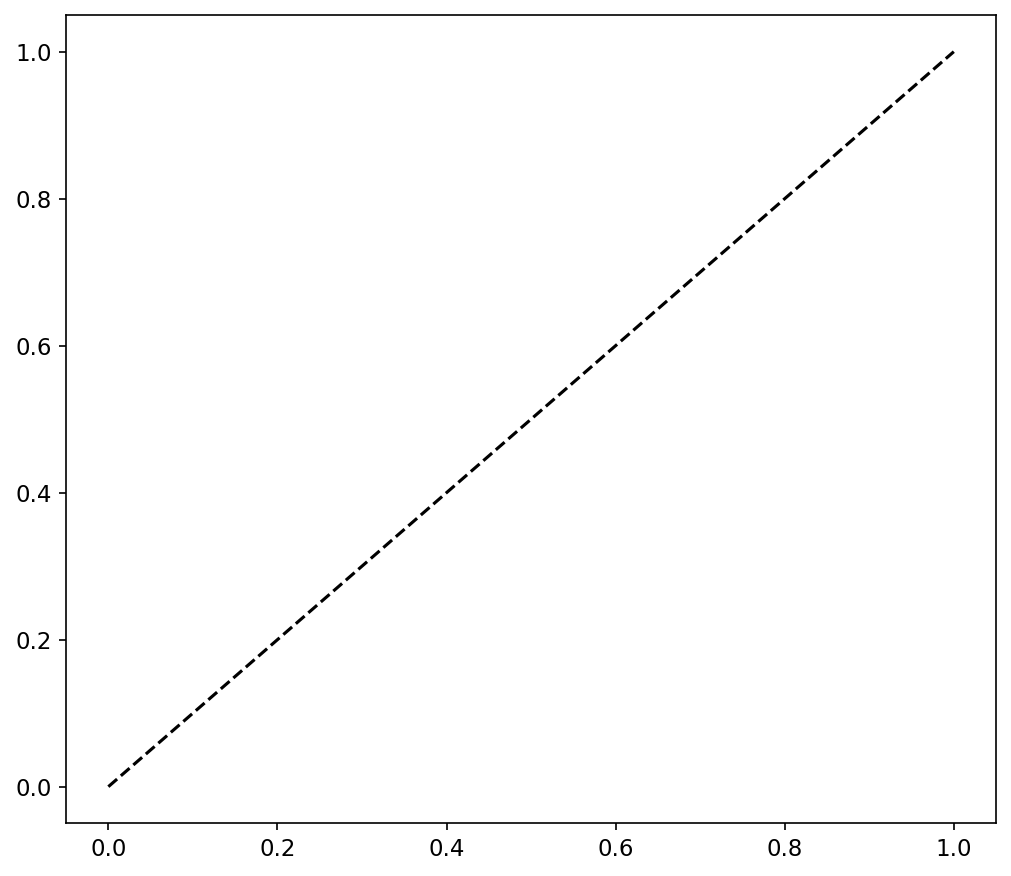

In [23]:
# CELL 19 — Calibration
fig,ax = plt.subplots(figsize=(8,7)); ax.plot([0,1],[0,1],'k--',label='Perfect')
for n,c in model_colors.items():
    fp,mp = calibration_curve(y_test, np.clip(results[n]['y_prob'][:,1],0,1), n_bins=10)
    ax.plot(mp,fp,marker='s',color=c,lw=2,label=n,ms=6)
ax.set_xlabel('Mean Predicted Prob'); ax.set_ylabel('Fraction Positives')
ax.set_title('Calibration Curve',fontsize=14,fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('calibration.png',dpi=200,bbox_inches='tight'); plt.show()

KeyError: 'ResNet-152'

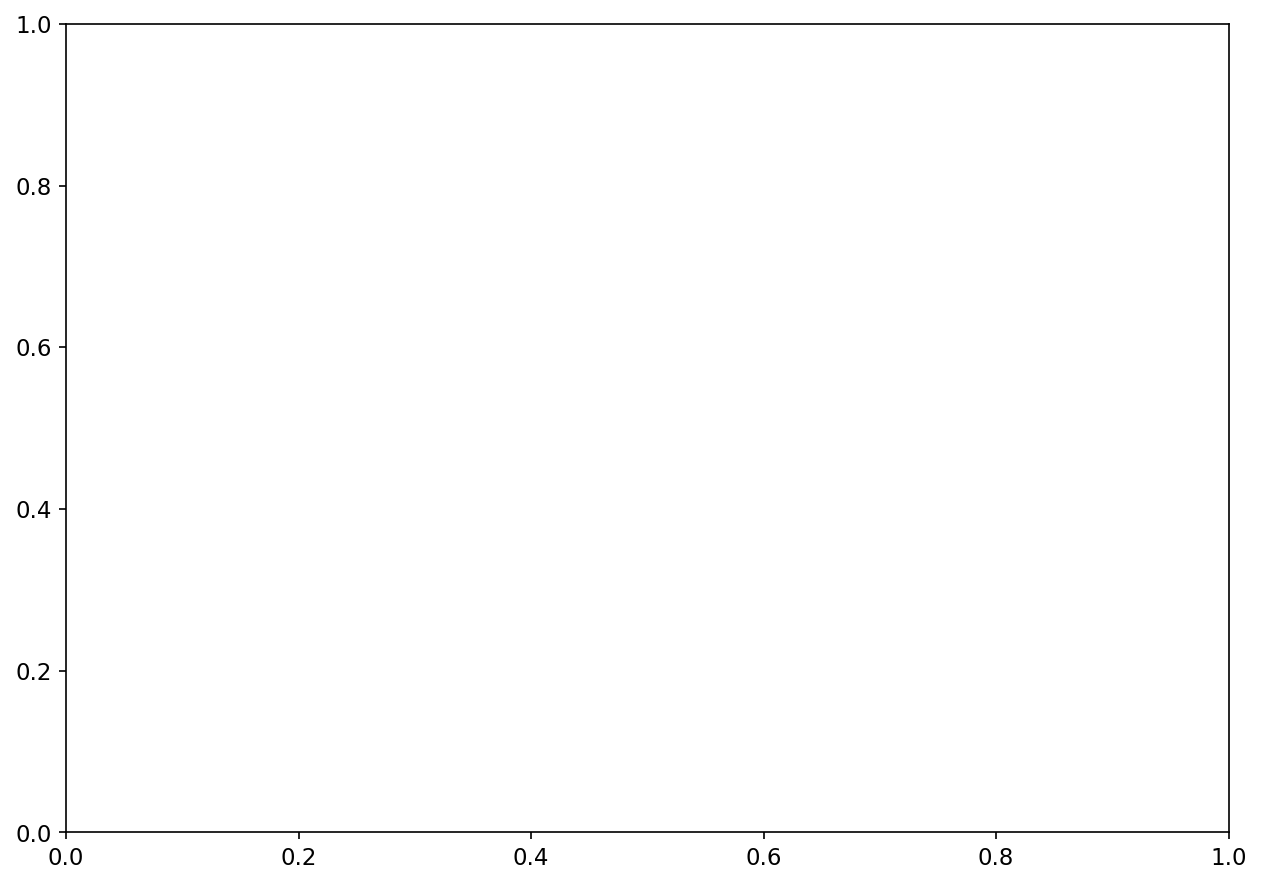

In [30]:
# CELL 20 — Forest Plot (FIXED)
def bootstrap_ci(yt, yp, fn, n_boot=300):
    sc = []
    for _ in range(n_boot):
        ix = np.random.choice(len(yt), len(yt), replace=True)
        try: sc.append(fn(yt[ix], yp[ix]))
        except: pass
    return np.mean(sc), np.percentile(sc, 2.5), np.percentile(sc, 97.5)

fmets = {
    'Accuracy':  accuracy_score,
    'F1':        lambda y, p: f1_score(y, p, average='weighted', zero_division=0),
    'Precision': lambda y, p: precision_score(y, p, average='weighted', zero_division=0),
    'Recall':    lambda y, p: recall_score(y, p, average='weighted', zero_division=0),
    'AUC':       lambda y, p: roc_auc_score(y, p),
}

fig, ax = plt.subplots(figsize=(10, 7)); pos = 0; ytl = []; yps = []
mnames = list(fmets.keys())
yt_int = y_test.astype(np.int32)
for mi, (mn, mf) in enumerate(fmets.items()):
    for n, c in model_colors.items():
        pred_ = results[n]['y_prob'][:, 1] if mn == 'AUC' else results[n]['y_pred']
        me, lo, hi = bootstrap_ci(yt_int, pred_, mf)
        ax.errorbar(me, pos, xerr=[[me-lo], [hi-me]], fmt='o', color=c, ms=8,
                    capsize=4, capthick=1.5, elinewidth=2,
                    markeredgecolor='black', markeredgewidth=0.5)
        ax.text(hi+0.005, pos, f'{me:.3f}', va='center', fontsize=9, color=c, fontweight='bold')
        ytl.append(n); yps.append(pos); pos += 1
    if mi < len(fmets)-1:
        ax.axhline(pos-0.5, color='gray', lw=0.5, alpha=0.3)
        pos += 0.5
ax.set_yticks(yps); ax.set_yticklabels(ytl, fontsize=9)
curr = 0
for mi, mn in enumerate(mnames):
    ax.text(1.06, curr+1, mn, transform=ax.get_yaxis_transform(),
            ha='left', va='center', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    curr += 3
    if mi < len(mnames)-1: curr += 0.5
ax.axvspan(0.95, 1,    alpha=0.06, color='green')
ax.axvspan(0.9,  0.95, alpha=0.06, color='yellow')
ax.axvspan(0.7,  0.9,  alpha=0.06, color='red')
ax.set_xlabel('Score'); ax.set_xlim([0.7, 1.05]); ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
ax.set_title('Forest Plot — 95% CI', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('forest.png', dpi=900, bbox_inches='tight'); plt.show()


---
## 7. Explainable AI

In [25]:
# CELL 21 — XAI Setup (pick samples from both ECG and PPG)
xai_model = models['QResNet-Fusion']
# 2 MI-ECG, 1 MI-PPG, 2 Normal-ECG, 1 Normal-PPG
mi_ecg = np.where((y_test==0)&(src_test==0))[0][:2]
mi_ppg = np.where((y_test==0)&(src_test==1))[0][:1]
no_ecg = np.where((y_test==1)&(src_test==0))[0][:2]
no_ppg = np.where((y_test==1)&(src_test==1))[0][:1]
xai_idx = np.concatenate([mi_ecg, mi_ppg, no_ecg, no_ppg])
xai_samples = X_test_c[xai_idx]
xai_labels  = y_test[xai_idx]
xai_sources = src_test[xai_idx]
print(f'XAI: {len(xai_idx)} samples')
for i in range(len(xai_idx)):
    print(f'  [{i}] {CLASS_NAMES[int(xai_labels[i])]} ({SOURCE_NAMES[xai_sources[i]]})')

XAI: 6 samples
  [0] MI (ECG)
  [1] MI (ECG)
  [2] MI (PPG)
  [3] Normal (ECG)
  [4] Normal (ECG)
  [5] Normal (PPG)


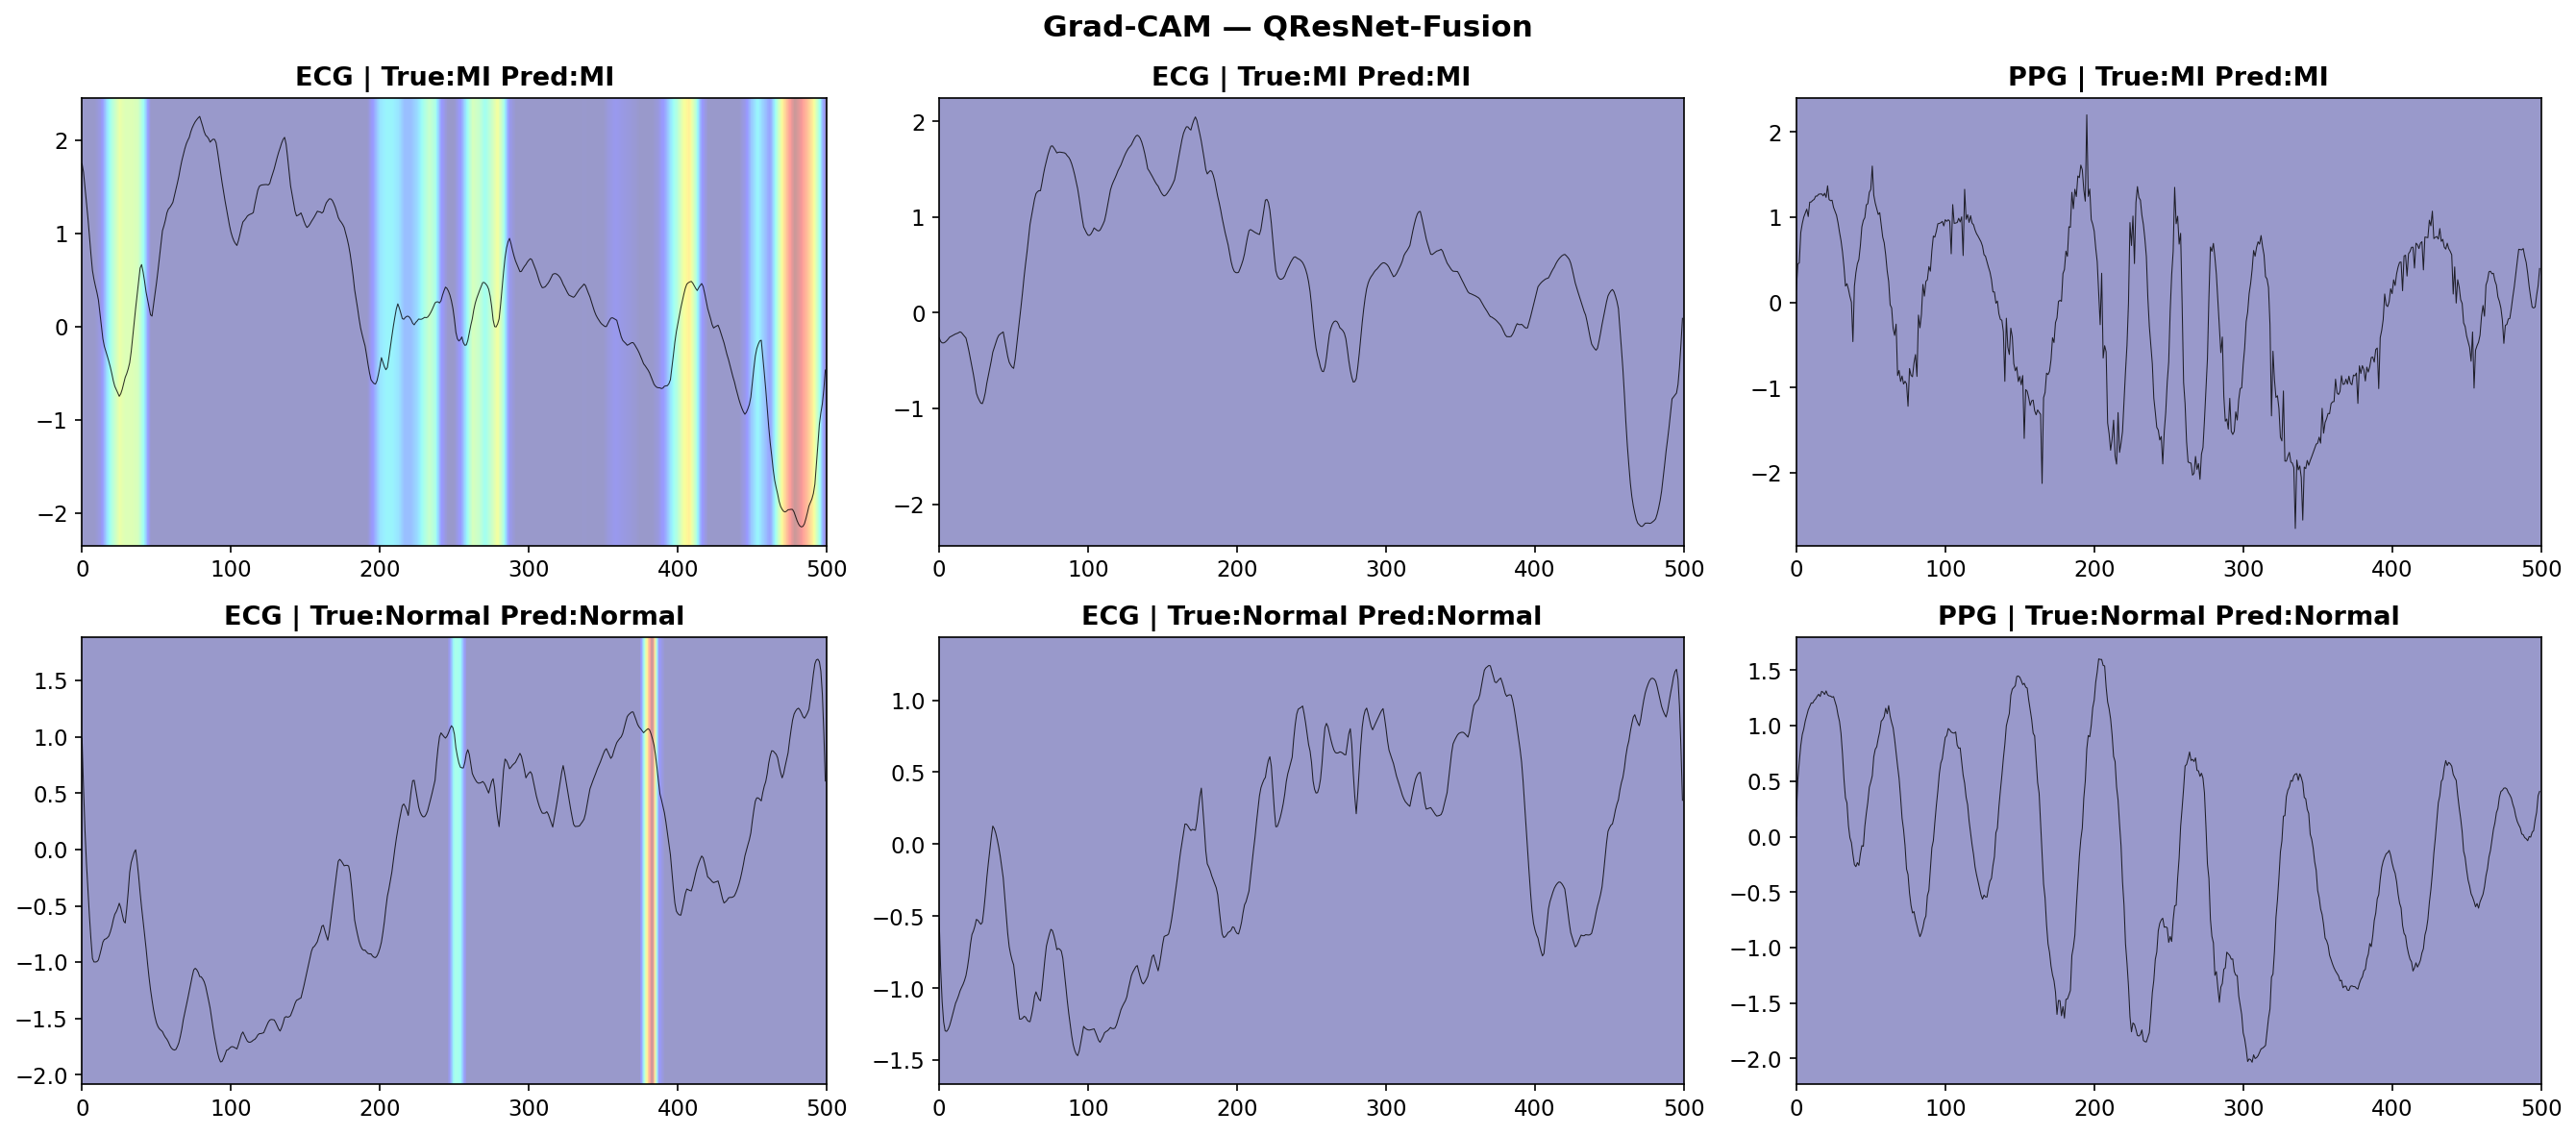

In [28]:
# CELL 22 — Grad-CAM (FIXED)
def grad_cam_1d(model, sample, class_idx):
    last_conv = None
    for l in reversed(model.layers):
        if isinstance(l, layers.Conv1D): last_conv = l.name; break
    gm = Model(model.input, [model.get_layer(last_conv).output, model.output])
    inp = tf.constant(sample[np.newaxis], dtype=tf.float32)
    with tf.GradientTape() as tape:
        co, pr = gm(inp)
        tape.watch(co)
        loss = pr[:, class_idx]
    g = tape.gradient(loss, co)
    if g is None:
        # Fallback: use input gradients
        inp_var = tf.Variable(sample[np.newaxis], dtype=tf.float32)
        with tf.GradientTape() as tape2:
            out = model(inp_var)[:, class_idx]
        g_inp = tape2.gradient(out, inp_var).numpy()[0].flatten()
        cam = np.abs(g_inp); cam /= (cam.max() + 1e-8)
        return cam
    cam = tf.reduce_sum(tf.reduce_mean(g, 1, keepdims=False) * co, axis=-1).numpy()[0]
    cam = np.maximum(cam, 0)
    if cam.max() > 0: cam /= cam.max()
    return interp1d(np.linspace(0, 1, len(cam)), cam)(np.linspace(0, 1, COMMON_LEN))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i in range(6):
    ax = axes[i//3, i%3]; s = xai_samples[i]; lb = int(xai_labels[i])
    pr = int(np.argmax(xai_model.predict(s[np.newaxis], verbose=0)))
    cam = grad_cam_1d(xai_model, s, pr); sig = s.flatten()
    ax.plot(sig, color='black', lw=0.5, alpha=0.8)
    ax.imshow(cam[np.newaxis, :], aspect='auto', cmap='jet', alpha=0.4,
              extent=[0, COMMON_LEN, sig.min()-0.2, sig.max()+0.2], origin='lower')
    src = SOURCE_NAMES[xai_sources[i]]
    ax.set_title(f'{src} | True:{CLASS_NAMES[lb]} Pred:{CLASS_NAMES[pr]}', fontweight='bold')
plt.suptitle('Grad-CAM — QResNet-Fusion', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('gradcam.png', dpi=900, bbox_inches='tight'); plt.show()


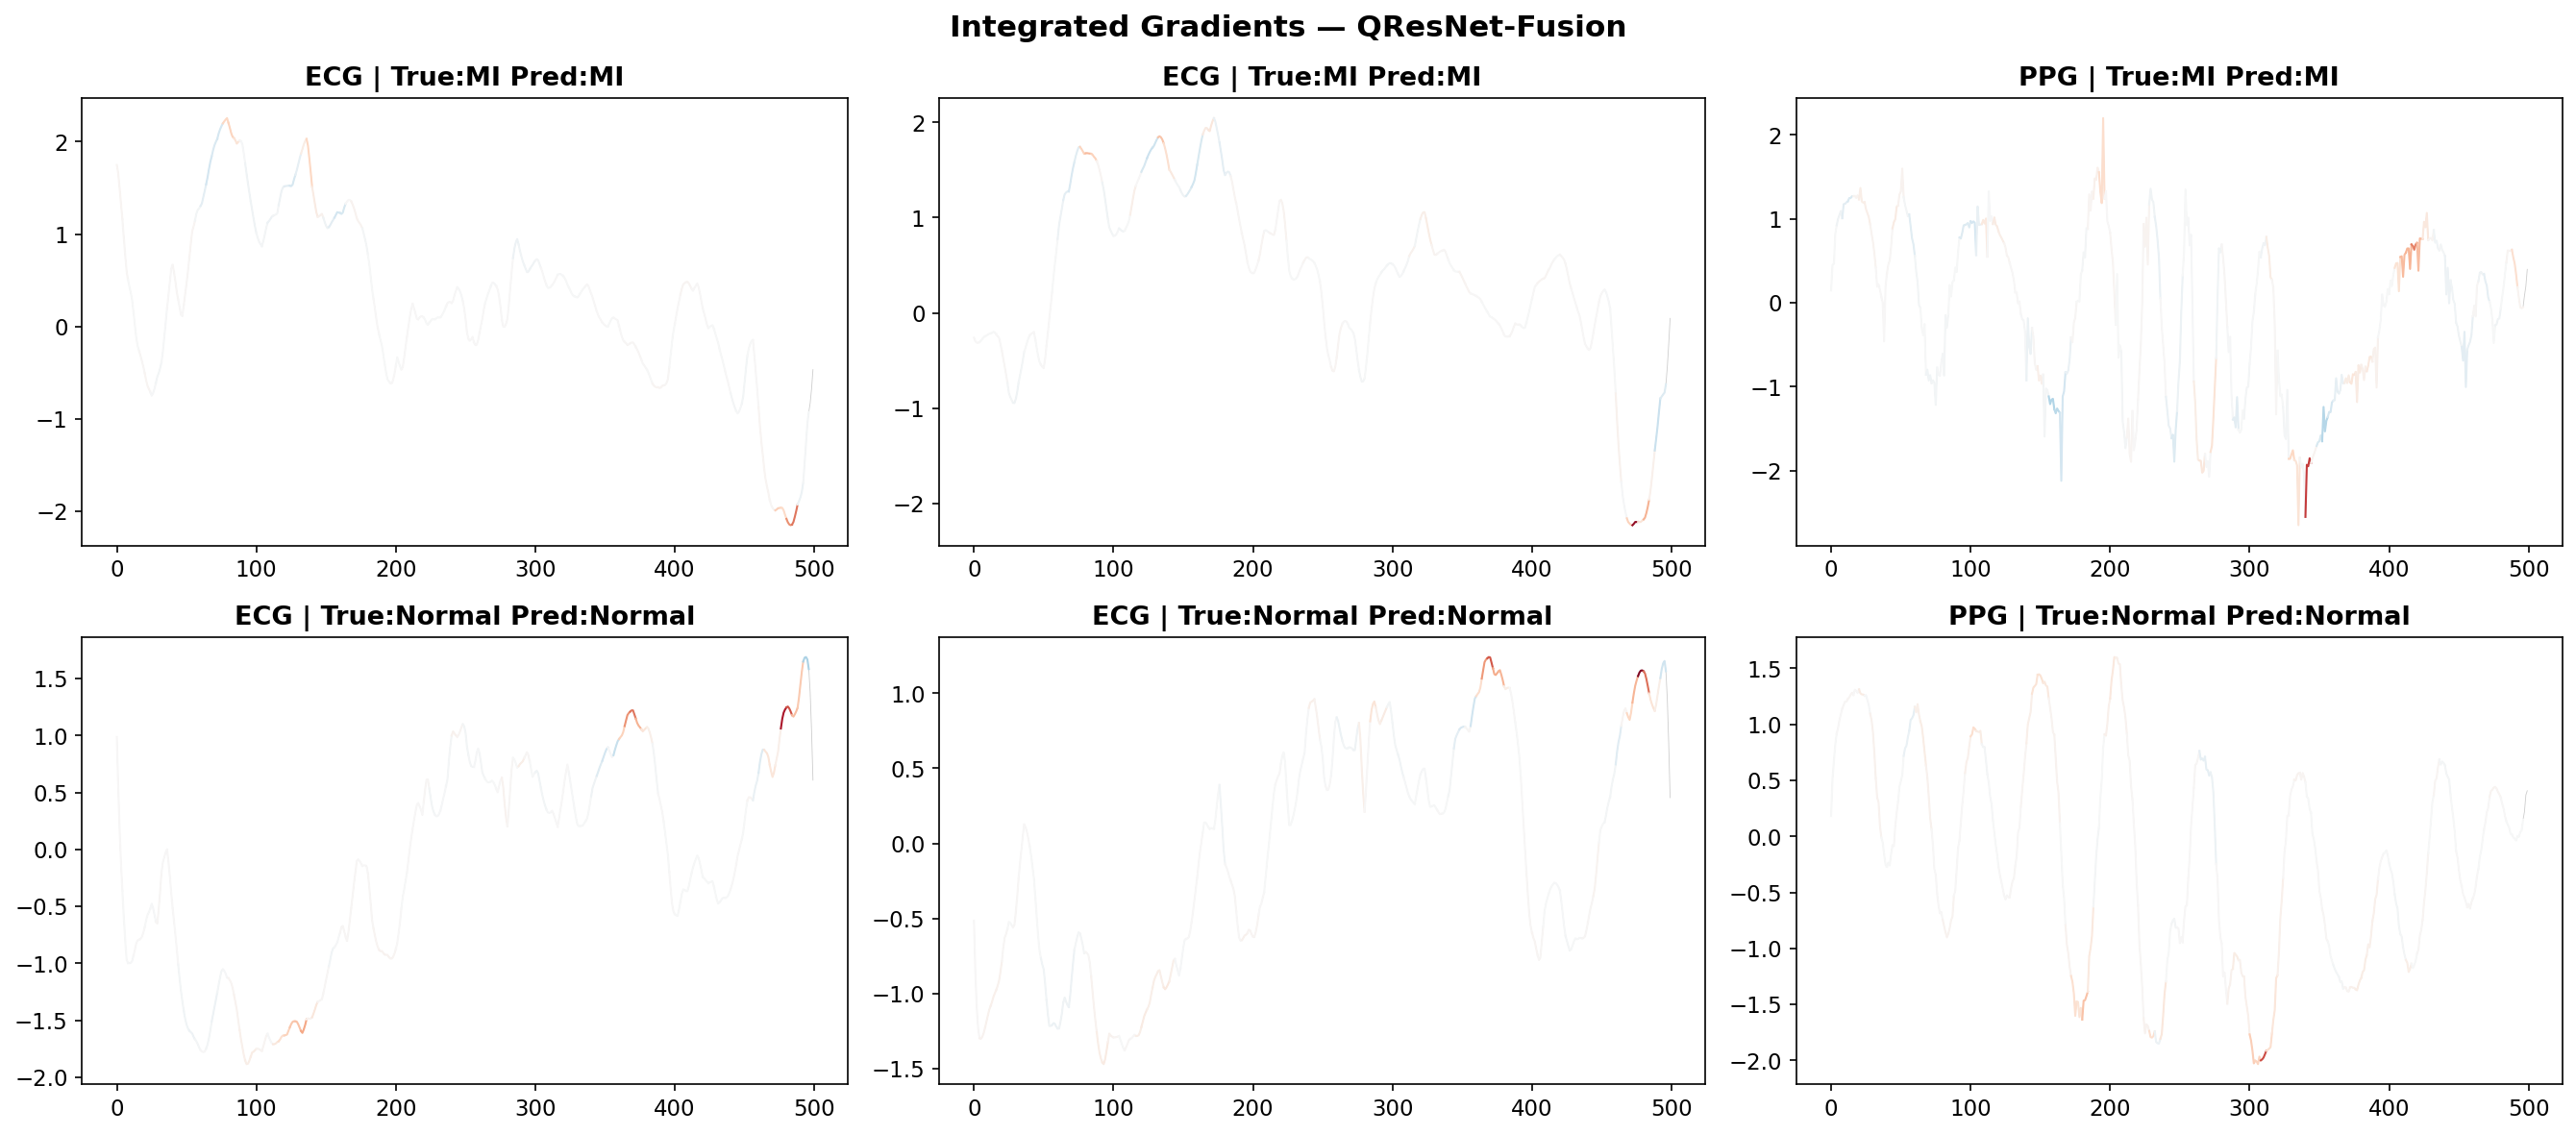

In [39]:
# CELL 23 — Integrated Gradients
def integrated_gradients(model, sample, class_idx, steps=50):
    bl = np.zeros_like(sample, dtype=np.float32)
    a = np.linspace(0,1,steps+1).reshape(-1,1,1).astype(np.float32)
    interp_inp = tf.constant(bl + a * (sample - bl), dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(interp_inp)
        tgt = model(interp_inp)[:, class_idx]
    grads = tape.gradient(tgt, interp_inp)
    return ((sample - bl) * tf.reduce_mean(grads, 0).numpy()).flatten()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i in range(6):
    ax = axes[i//3, i%3]; s = xai_samples[i]; lb = int(xai_labels[i])
    pr = int(np.argmax(xai_model.predict(s[np.newaxis], verbose=0)))
    ig = integrated_gradients(xai_model, s, pr); sig = s.flatten()
    ig_n = ig / (np.abs(ig).max() + 1e-8)
    ax.plot(sig, color='gray', lw=0.4, alpha=0.4)
    cmap = plt.cm.RdBu_r
    step = 4
    for t in range(0, COMMON_LEN-step, step):
        ax.plot(range(t,t+step+1), sig[t:t+step+1], color=cmap((ig_n[t]+1)/2), lw=1)
    src = SOURCE_NAMES[xai_sources[i]]
    ax.set_title(f'{src} | True:{CLASS_NAMES[lb]} Pred:{CLASS_NAMES[pr]}', fontweight='bold')
plt.suptitle('Integrated Gradients — QResNet-Fusion', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('ig.png',dpi=200,bbox_inches='tight'); plt.show()

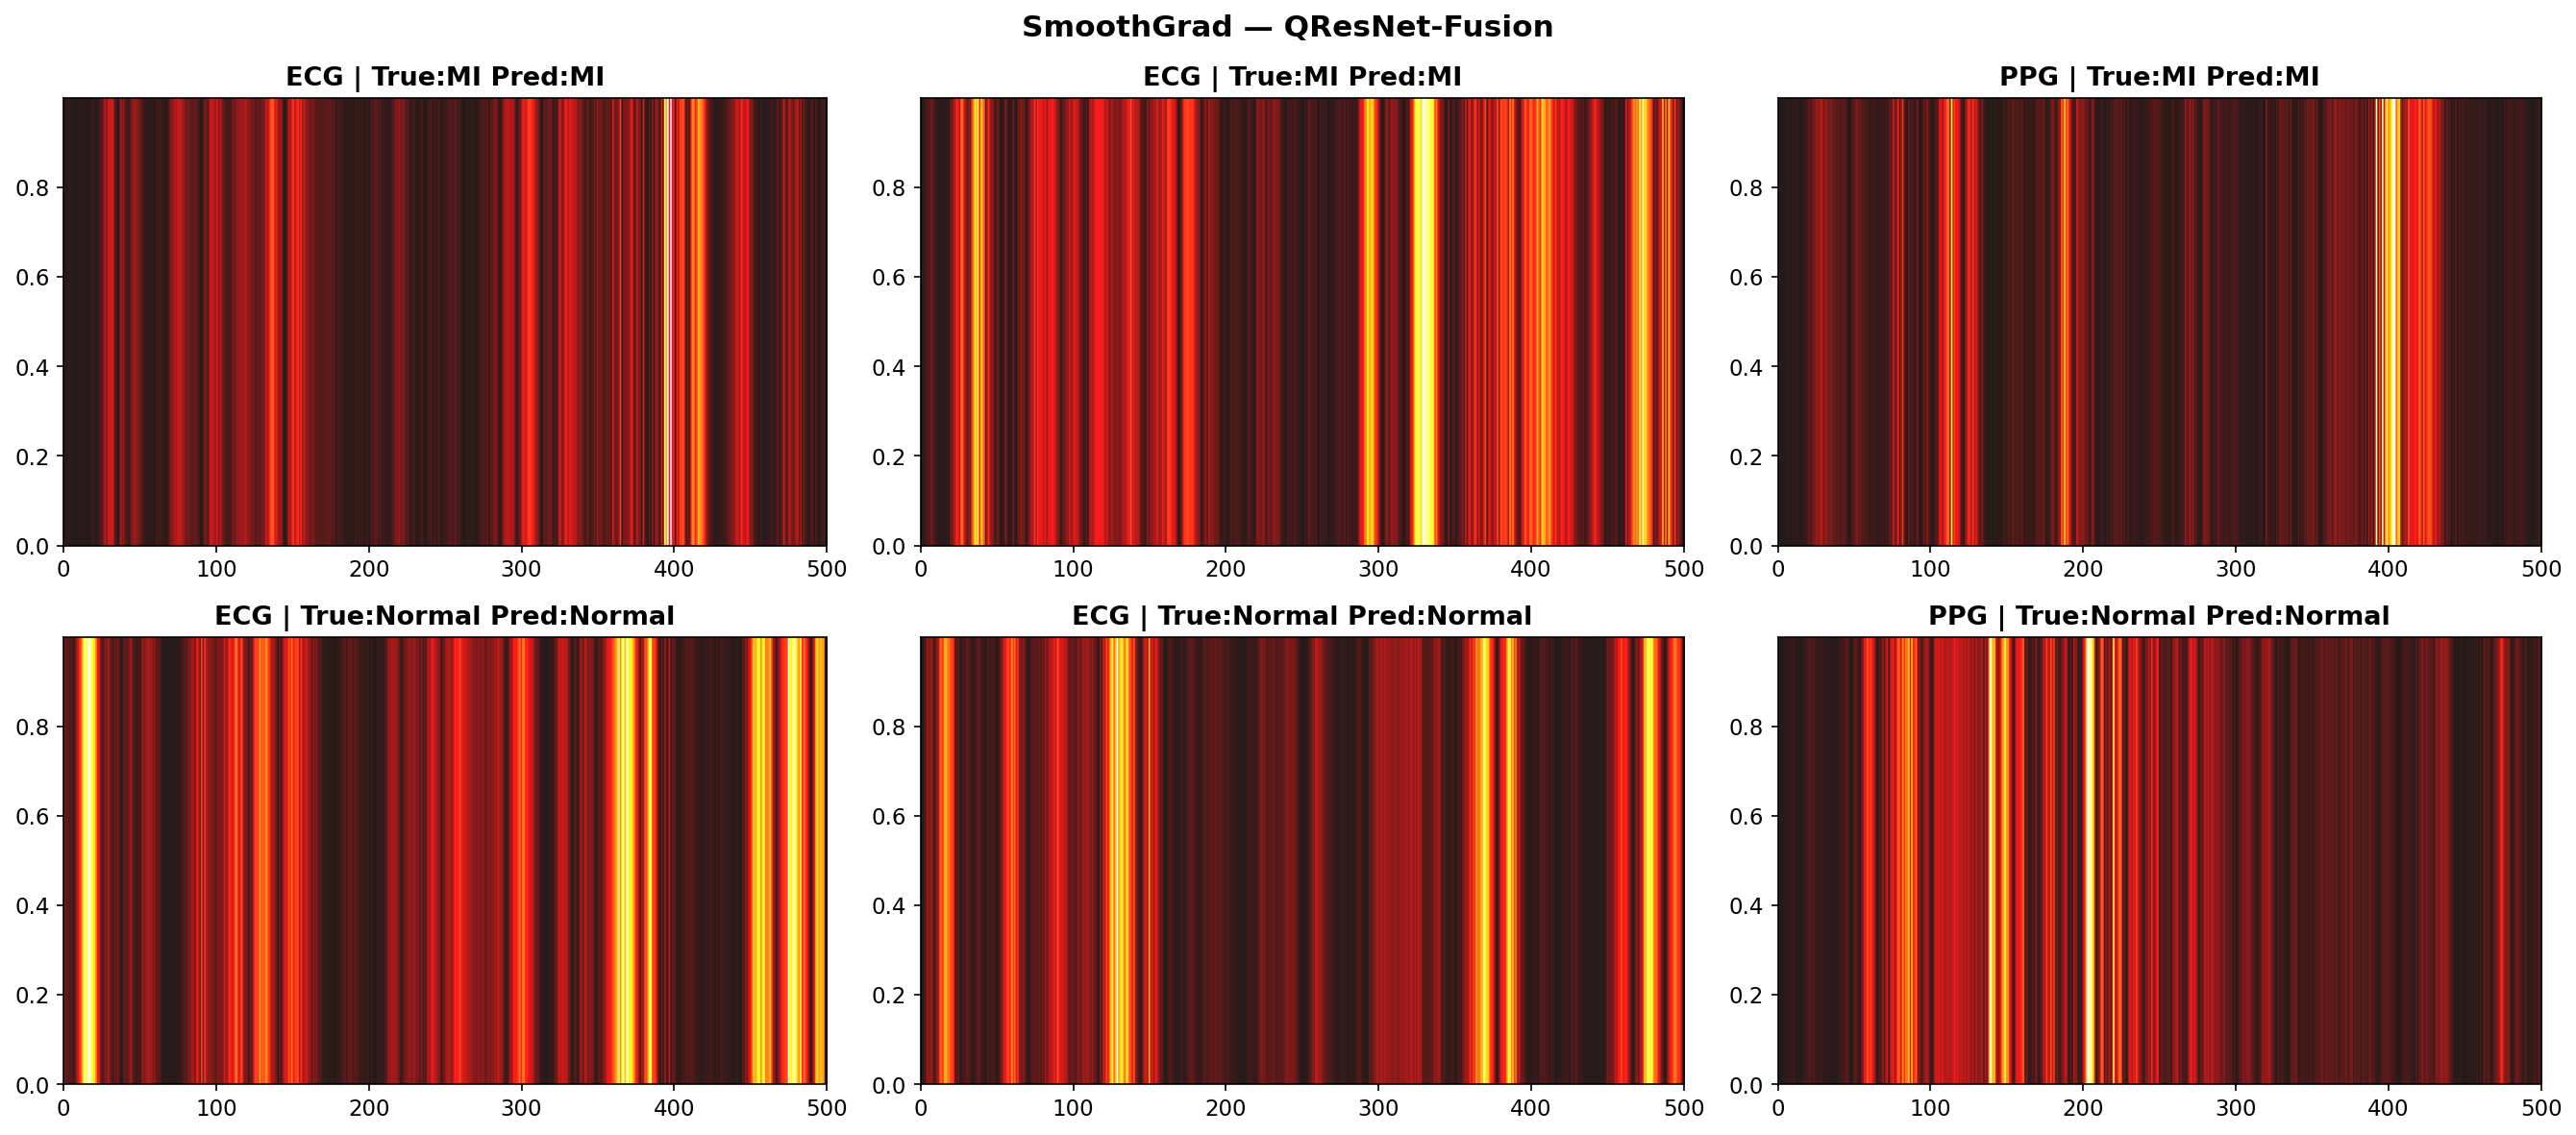

In [38]:
# CELL 24 — SmoothGrad
def smoothgrad_fn(model, sample, class_idx, n_samples=50, noise_level=0.1):
    sd = noise_level * (float(sample.max()) - float(sample.min()) + 1e-8)
    total = np.zeros_like(sample, dtype=np.float32)
    for _ in range(n_samples):
        noisy = sample + np.random.normal(0, sd, sample.shape).astype(np.float32)
        nt = tf.constant(noisy[np.newaxis], dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(nt); tgt = model(nt)[:, class_idx]
        total += tape.gradient(tgt, nt).numpy()[0]
    return (total / n_samples).flatten()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i in range(6):
    ax = axes[i//3, i%3]; s = xai_samples[i]; lb = int(xai_labels[i])
    pr = int(np.argmax(xai_model.predict(s[np.newaxis], verbose=0)))
    sg = smoothgrad_fn(xai_model, s, pr, 50)
    sg_n = np.abs(sg); sg_n /= (sg_n.max() + 1e-8)
    ax.imshow(sg_n[np.newaxis,:], aspect='auto', cmap='hot',
              extent=[0,COMMON_LEN,0,sg_n.max()], origin='lower', alpha=0.9)
    src = SOURCE_NAMES[xai_sources[i]]
    ax.set_title(f'{src} | True:{CLASS_NAMES[lb]} Pred:{CLASS_NAMES[pr]}', fontweight='bold')
plt.suptitle('SmoothGrad — QResNet-Fusion', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('smoothgrad.png',dpi=200,bbox_inches='tight'); plt.show()

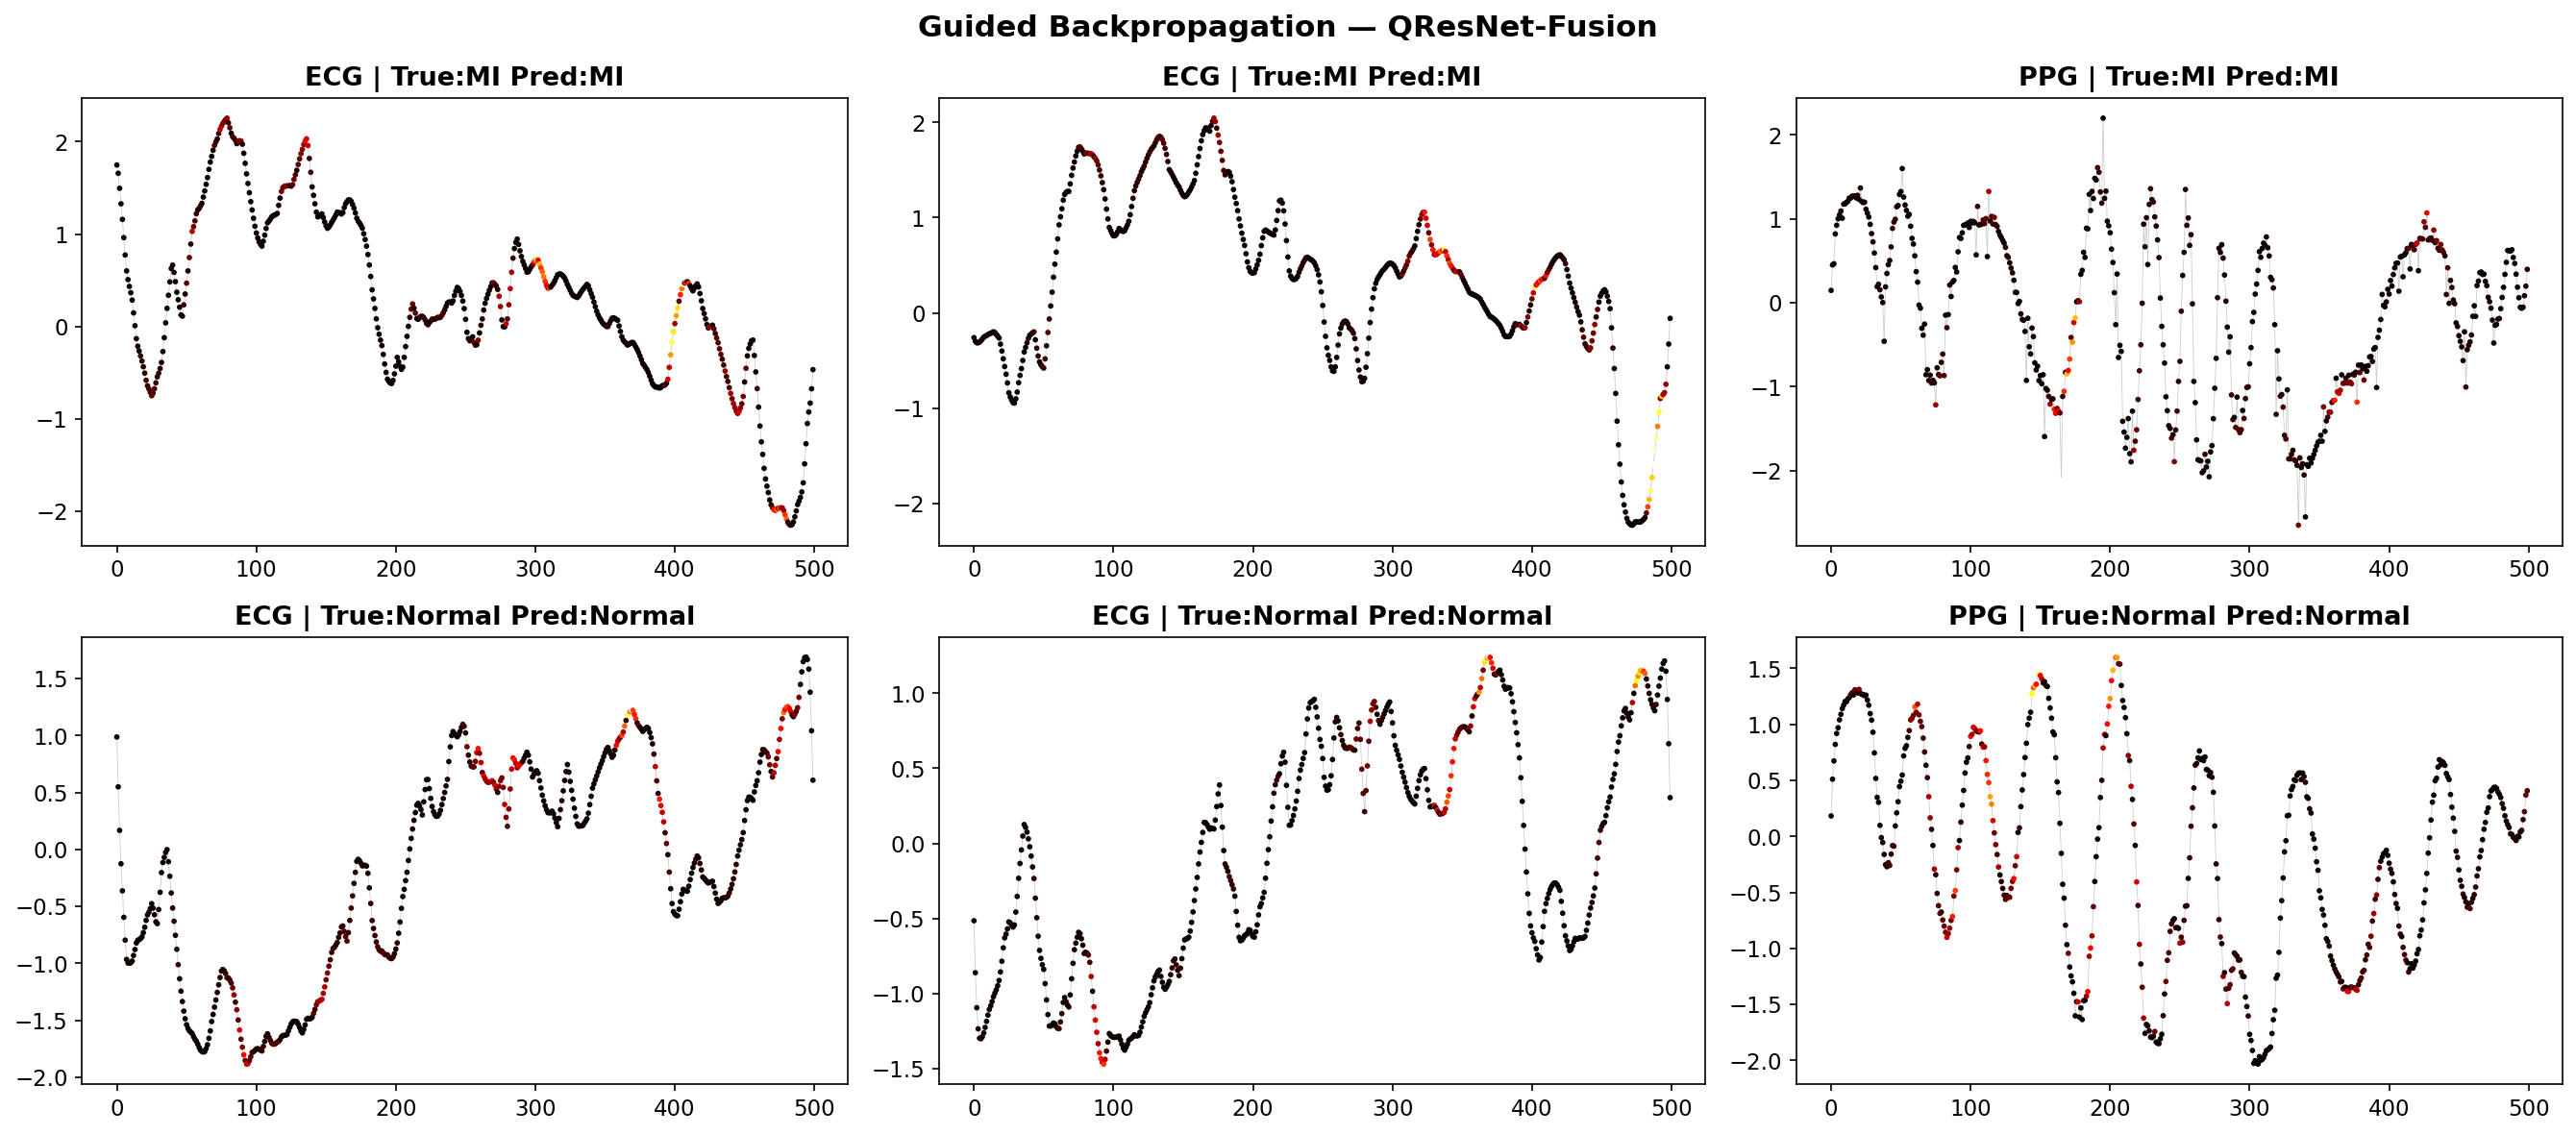

In [37]:
# CELL 25 — Guided Backpropagation
def guided_backprop(model, sample, class_idx):
    iv = tf.Variable(tf.constant(sample[np.newaxis], dtype=tf.float32))
    with tf.GradientTape() as tape:
        tgt = model(iv, training=False)[:, class_idx]
    grads = tape.gradient(tgt, iv).numpy()[0]
    return np.maximum(grads, 0).flatten()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i in range(6):
    ax = axes[i//3, i%3]; s = xai_samples[i]; lb = int(xai_labels[i])
    pr = int(np.argmax(xai_model.predict(s[np.newaxis], verbose=0)))
    gb = guided_backprop(xai_model, s, pr); sig = s.flatten()
    gb_n = gb / (gb.max() + 1e-8)
    ax.plot(sig, color='gray', lw=0.4, alpha=0.4)
    ax.scatter(range(COMMON_LEN), sig, c=gb_n, cmap='hot', s=3, zorder=5)
    src = SOURCE_NAMES[xai_sources[i]]
    ax.set_title(f'{src} | True:{CLASS_NAMES[lb]} Pred:{CLASS_NAMES[pr]}', fontweight='bold')
plt.suptitle('Guided Backpropagation — QResNet-Fusion', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('gbp.png',dpi=200,bbox_inches='tight'); plt.show()

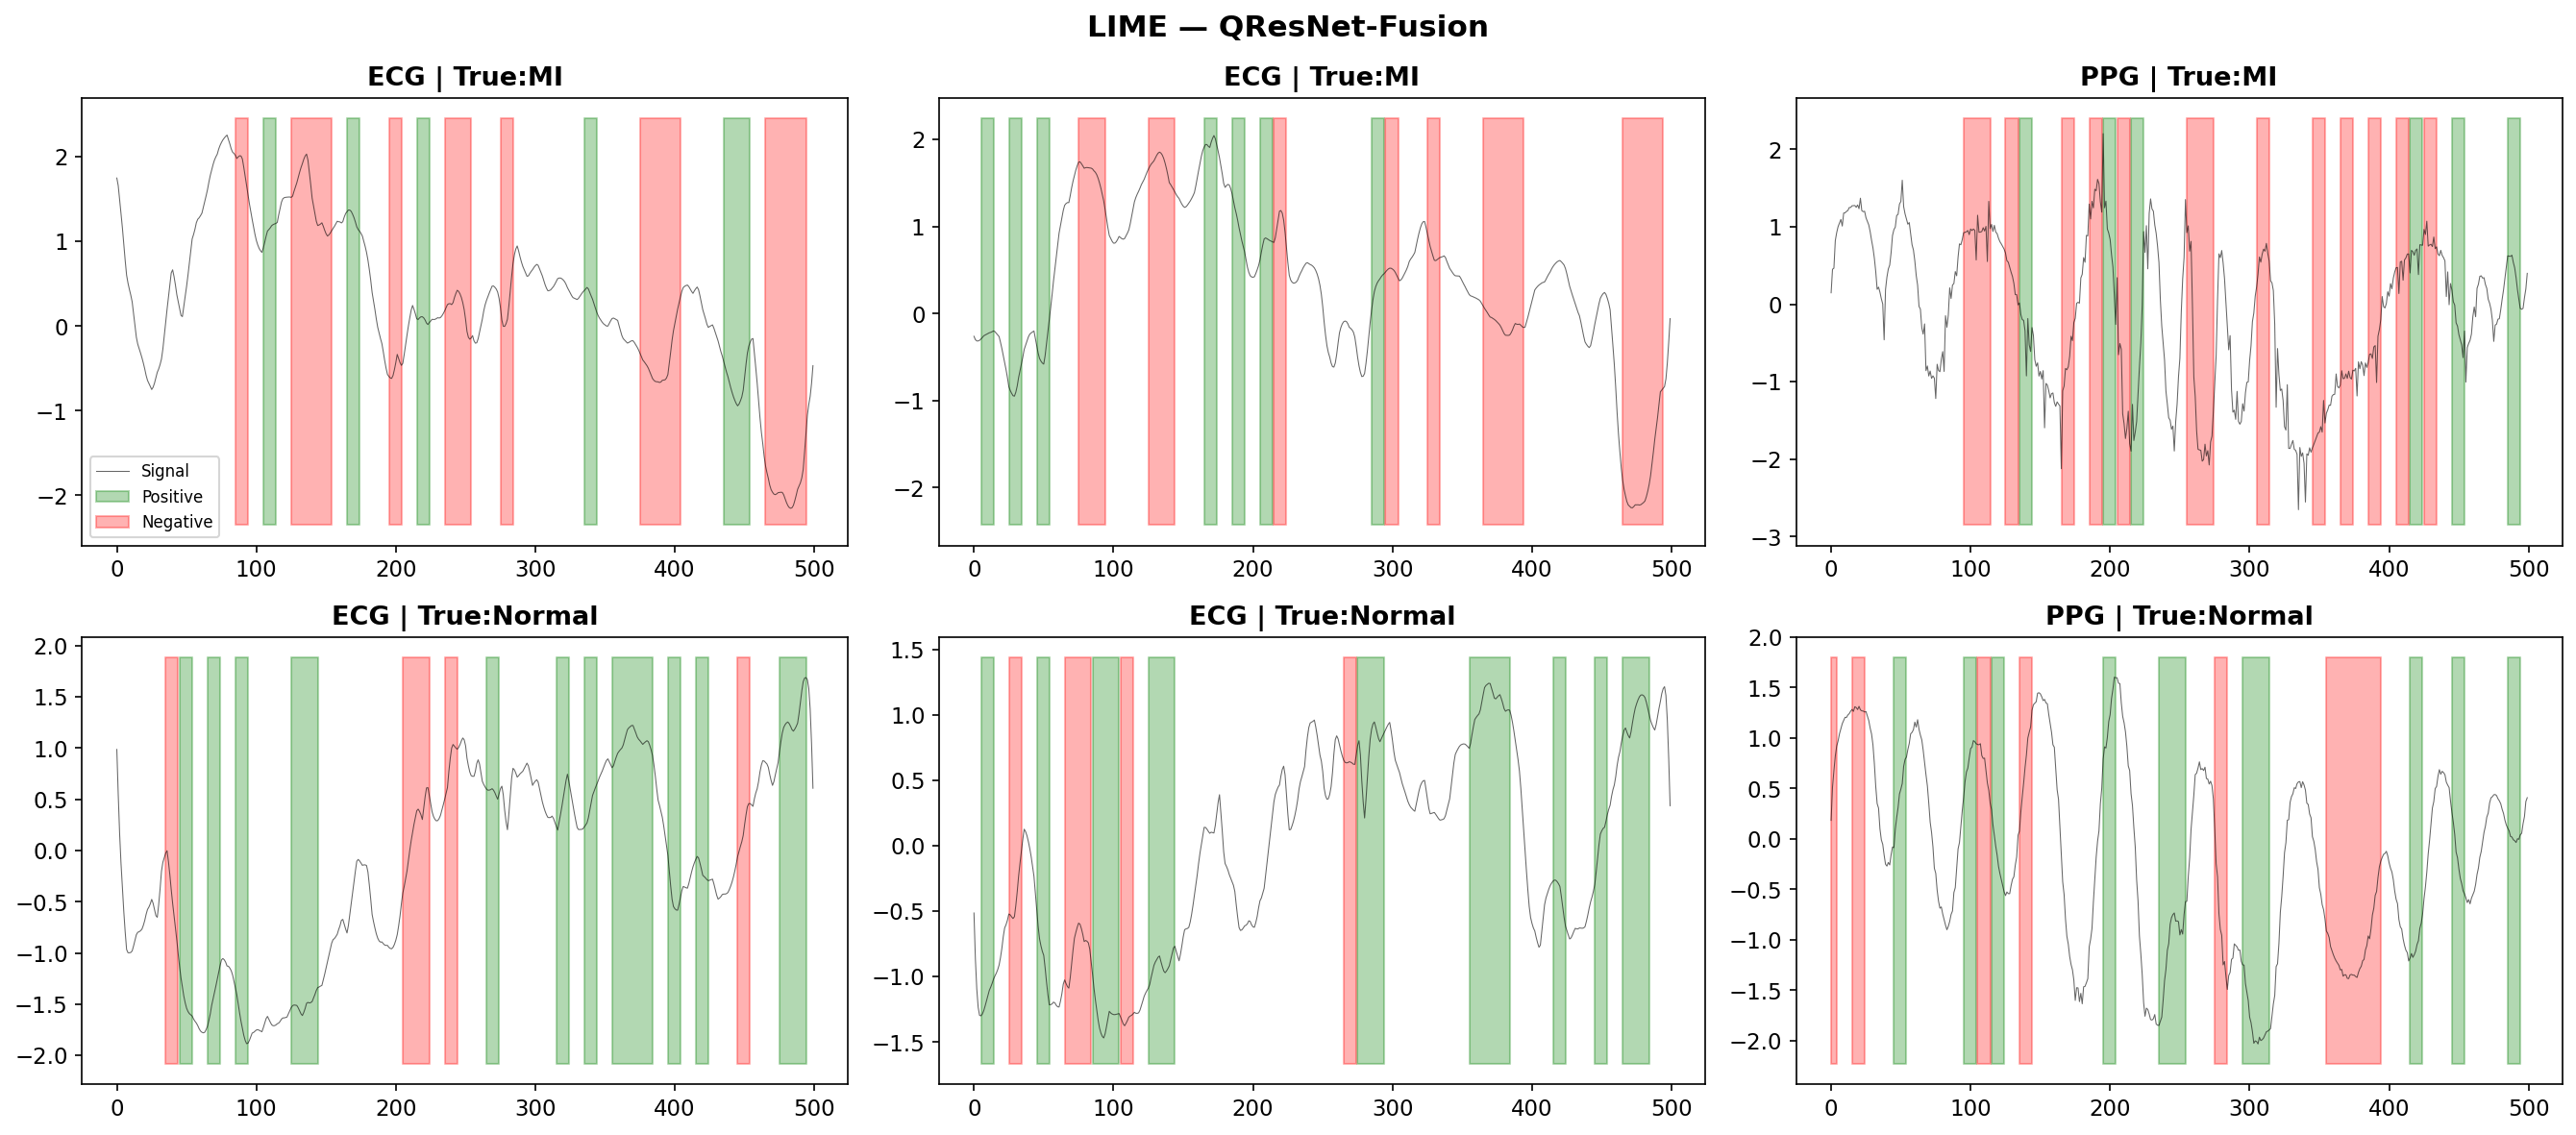

In [36]:
# CELL 26 — LIME
import lime, lime.lime_tabular
LIME_STEP = 10
lime_idx = list(range(0, COMMON_LEN, LIME_STEP))
def lime_predict(Xsub):
    n = Xsub.shape[0]
    Xfull = np.zeros((n, COMMON_LEN), dtype=np.float32)
    for k in range(n): Xfull[k] = np.interp(np.arange(COMMON_LEN), lime_idx, Xsub[k])
    p = xai_model.predict(Xfull.reshape(-1,COMMON_LEN,1), verbose=0)
    return p / (p.sum(1, keepdims=True) + 1e-8)

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train[:, lime_idx], feature_names=[f't{i}' for i in lime_idx],
    class_names=CLASS_NAMES, mode='classification')

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i in range(6):
    ax = axes[i//3, i%3]; sf = xai_samples[i].flatten(); lb = int(xai_labels[i])
    exp = explainer.explain_instance(sf[lime_idx], lime_predict, num_features=20, num_samples=300)
    imp = np.zeros(COMMON_LEN)
    for fn_str, w in dict(exp.as_list()).items():
        for part in fn_str.split():
            if part.startswith('t') and part[1:].isdigit():
                fi = int(part[1:])
                lo = max(0, fi - LIME_STEP//2)
                hi = min(COMMON_LEN, fi + LIME_STEP//2)
                imp[lo:hi] = w
                break
    ax.plot(sf, color='black', lw=0.5, alpha=0.6)
    ax.fill_between(range(COMMON_LEN), sf.min()-0.2, sf.max()+0.2,
                     where=imp>0, alpha=0.3, color='green')
    ax.fill_between(range(COMMON_LEN), sf.min()-0.2, sf.max()+0.2,
                     where=imp<0, alpha=0.3, color='red')
    src = SOURCE_NAMES[xai_sources[i]]
    ax.set_title(f'{src} | True:{CLASS_NAMES[lb]}', fontweight='bold')
    if i == 0: ax.legend(['Signal','Positive','Negative'], fontsize=8)
plt.suptitle('LIME — QResNet-Fusion', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('lime.png',dpi=200,bbox_inches='tight'); plt.show()

In [35]:
# CELL 27 — Combined XAI
s = xai_samples[0]; lb = int(xai_labels[0])
pr = int(np.argmax(xai_model.predict(s[np.newaxis], verbose=0))); sig = s.flatten()
cam = grad_cam_1d(xai_model, s, pr)
ig_v = np.abs(integrated_gradients(xai_model, s, pr)); ig_v /= (ig_v.max()+1e-8)
sg_v = np.abs(smoothgrad_fn(xai_model, s, pr, 50)); sg_v /= (sg_v.max()+1e-8)
gb_v = guided_backprop(xai_model, s, pr); gb_v /= (gb_v.max()+1e-8)

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
for ai,(ax,tt,d,cm) in enumerate(zip(axes,
    ['Original Signal','Grad-CAM','Integrated Gradients','SmoothGrad','Guided Backprop'],
    [sig,cam,ig_v,sg_v,gb_v], [None,'jet','RdBu_r','hot','hot'])):
    if ai == 0: ax.plot(d, color='black', lw=0.8)
    else:
        ax.plot(sig, color='gray', lw=0.3, alpha=0.3)
        ax.imshow(d[np.newaxis,:], aspect='auto', cmap=cm, alpha=0.6,
                  extent=[0,COMMON_LEN,sig.min()-0.2,sig.max()+0.2], origin='lower')
    ax.set_title(tt, fontweight='bold'); ax.grid(alpha=0.2)
axes[-1].set_xlabel('Time Step')
src = SOURCE_NAMES[xai_sources[0]]
fig.suptitle(f'XAI Comparison — {src} | True:{CLASS_NAMES[lb]} Pred:{CLASS_NAMES[pr]}',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('xai_comp.png',dpi=200,bbox_inches='tight'); plt.show()

NameError: name 'integrated_gradients' is not defined

---
## 8. Summary


FINAL MODEL COMPARISON
         Model    Params    Acc   Prec    Rec     F1    AUC    MCC   Jacc
        ResNet 1,412,096 0.9881 0.9881 0.9881 0.9881 0.9978 0.9760 0.9765
          QSVM   112,704 0.9921 0.9921 0.9921 0.9921 0.9976 0.9840 0.9843
QResNet-Fusion   853,536 0.9934 0.9934 0.9934 0.9934 0.9976 0.9867 0.9869


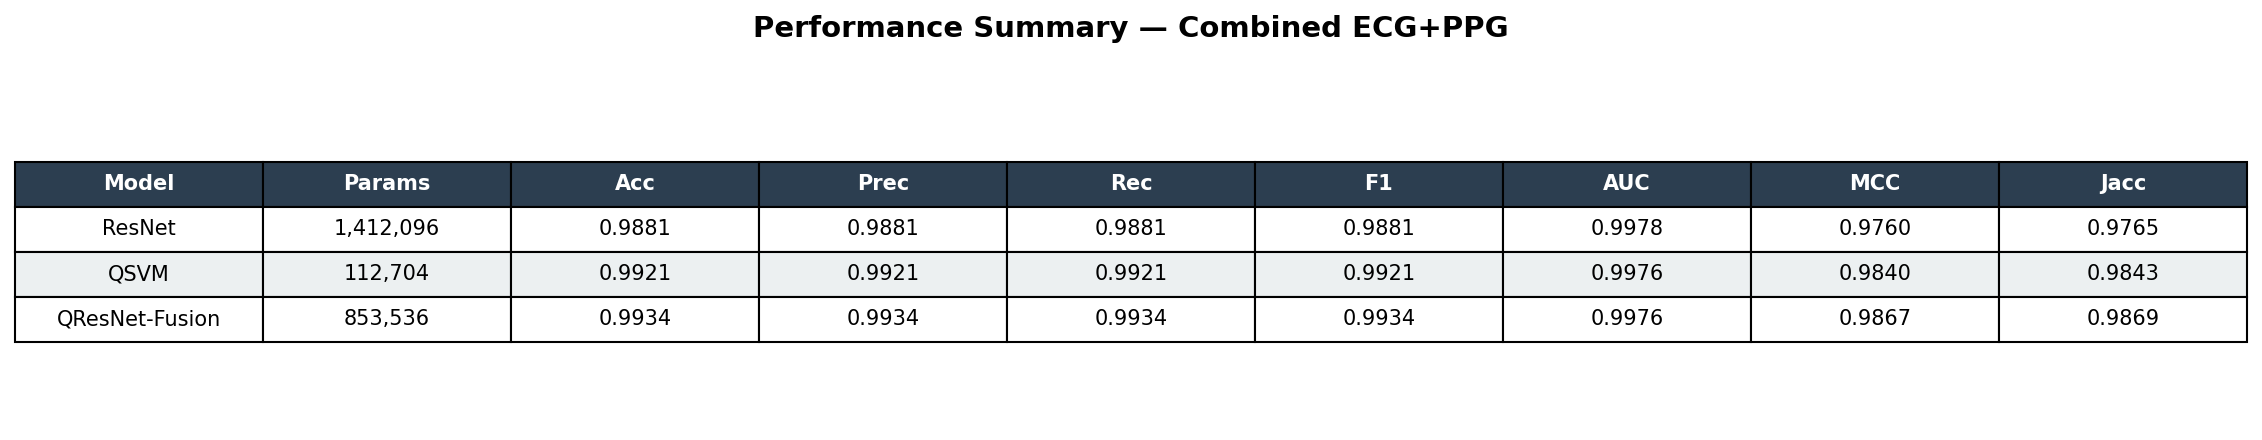

KeyError: 'ResNet-152'

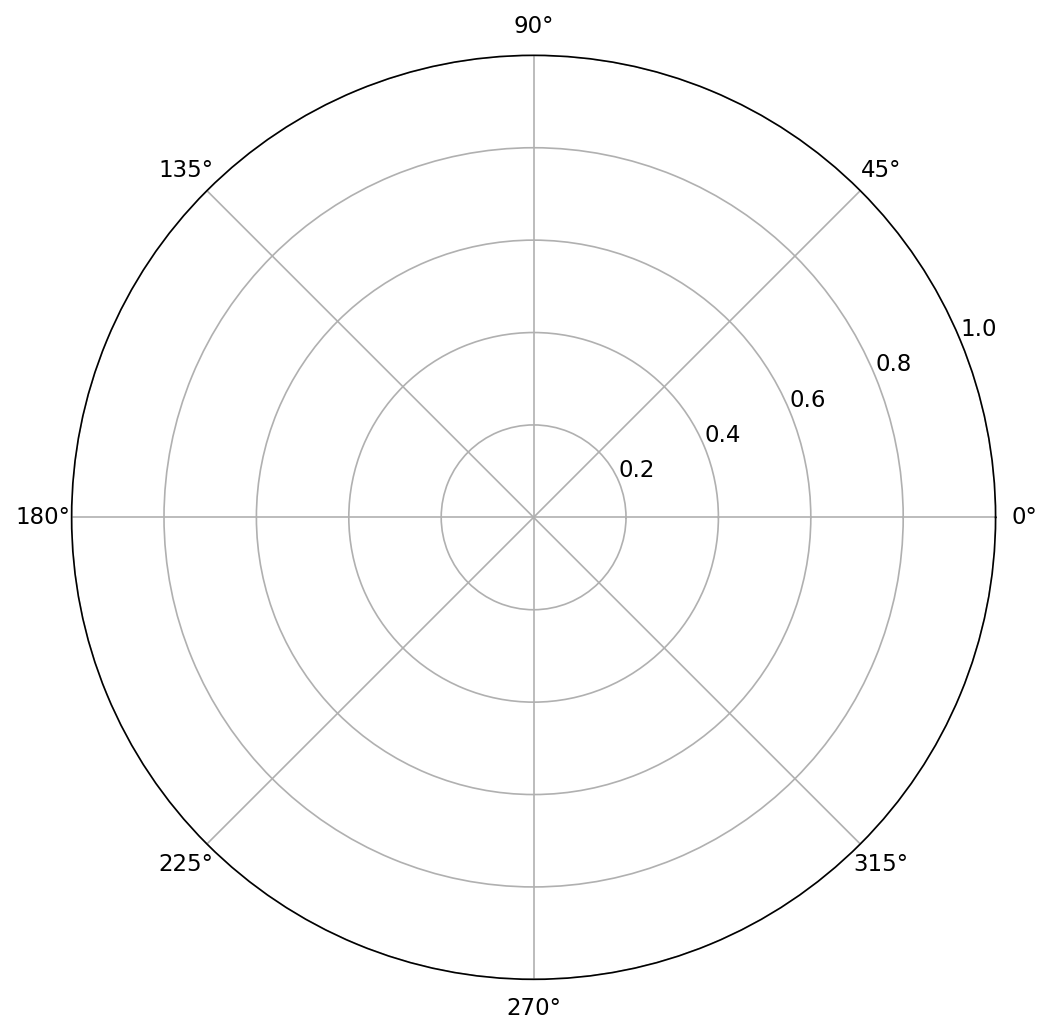

In [34]:
# CELL 28 — Summary + Radar
rows = []
for n in models:
    r = results[n]
    rows.append({'Model':n,'Params':f"{models[n].count_params():,}",'Acc':f"{r['accuracy']:.4f}",
        'Prec':f"{r['precision']:.4f}",'Rec':f"{r['recall']:.4f}",'F1':f"{r['f1']:.4f}",
        'AUC':f"{r['auc']:.4f}",'MCC':f"{r['mcc']:.4f}",'Jacc':f"{r['jaccard']:.4f}"})
sdf = pd.DataFrame(rows)
print('\n'+'='*90+'\nFINAL MODEL COMPARISON\n'+'='*90)
print(sdf.to_string(index=False))

fig,ax = plt.subplots(figsize=(16,3)); ax.axis('off')
tb = ax.table(cellText=sdf.values, colLabels=sdf.columns, cellLoc='center', loc='center')
tb.auto_set_font_size(False); tb.set_fontsize(10); tb.scale(1.2,1.8)
for (r,c),cell in tb.get_celld().items():
    if r==0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white',fontweight='bold')
    elif r%2==0: cell.set_facecolor('#ecf0f1')
plt.title('Performance Summary — Combined ECG+PPG',fontsize=14,fontweight='bold',pad=20)
plt.savefig('summary.png',dpi=200,bbox_inches='tight'); plt.show()

rmets = ['Accuracy','Precision','Recall','F1','AUC','MCC']
angles = np.linspace(0,2*np.pi,len(rmets),endpoint=False).tolist(); angles += angles[:1]
fig,ax = plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
for n,c in model_colors.items():
    r = results[n]
    v = [r['accuracy'],r['precision'],r['recall'],r['f1'],r['auc'],r['mcc']]; v += v[:1]
    ax.plot(angles,v,'o-',color=c,lw=2,label=n,ms=6); ax.fill(angles,v,alpha=0.1,color=c)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(rmets); ax.set_ylim([0.6,1.05])
ax.legend(loc='upper right',bbox_to_anchor=(1.3,1.1))
ax.set_title('Radar Comparison',fontsize=14,fontweight='bold',pad=20)
plt.tight_layout(); plt.savefig('radar.png',dpi=200,bbox_inches='tight'); plt.show()

In [33]:
# CELL 29 — Classification Reports (FIXED)
yt_int = y_test.astype(np.int32)
for n in models:
    print(f'\n{"="*60}\n{n}\n{"="*60}')
    print(classification_report(yt_int, results[n]['y_pred'].astype(np.int32),
                                 target_names=CLASS_NAMES, digits=4))

print(f'\n{"="*60}\nPER-SOURCE ACCURACY (HybridNet)\n{"="*60}')
for sv, sn in enumerate(SOURCE_NAMES):
    mask = src_test == sv
    if mask.sum() > 0:
        acc = accuracy_score(yt_int[mask], results['HybridNet']['y_pred'][mask].astype(np.int32))
        print(f'  {sn}: {acc:.4f}  (n={int(mask.sum())})')



ResNet
              precision    recall  f1-score   support

          MI     0.9881    0.9852    0.9867       338
      Normal     0.9881    0.9905    0.9893       420

    accuracy                         0.9881       758
   macro avg     0.9881    0.9878    0.9880       758
weighted avg     0.9881    0.9881    0.9881       758


QSVM
              precision    recall  f1-score   support

          MI     0.9911    0.9911    0.9911       338
      Normal     0.9929    0.9929    0.9929       420

    accuracy                         0.9921       758
   macro avg     0.9920    0.9920    0.9920       758
weighted avg     0.9921    0.9921    0.9921       758


QResNet-Fusion
              precision    recall  f1-score   support

          MI     0.9941    0.9911    0.9926       338
      Normal     0.9929    0.9952    0.9941       420

    accuracy                         0.9934       758
   macro avg     0.9935    0.9932    0.9933       758
weighted avg     0.9934    0.9934    0.9934 

KeyError: 'HybridNet'

In [32]:
# CELL 30 — Download
saved = sorted(glob.glob('*.png'))
print(f'{len(saved)} figures:')
for i,f in enumerate(saved,1): print(f'  {i:2d}. {f}')
!zip -q combined_figures.zip *.png
from google.colab import files as colab_files
colab_files.download('combined_figures.zip')
print('\n\u2705 Notebook complete!')

5 figures:
   1. ablation.png
   2. cm.png
   3. dataset_vis.png
   4. gradcam.png
   5. tsne.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Notebook complete!
